# DML Inference: Impact of 401(k) on Financial Wealth

In this real-data example, we illustrate how the DML package can be used to estimate the effect of 401(k) eligibility and participation on accumulated assets. The 401(k) data set has been analyzed in several studies, among others Chernozhukov et al. (2018).

401(k) plans are pension accounts sponsored by employers. The key problem in determining the effect of participation in 401(k) plans on accumulated assets is saver heterogeneity coupled with the fact that the decision to enroll in a 401(k) is non-random. It is generally recognized that some people have a higher preference for saving than others. It also seems likely that those individuals with high unobserved preference for saving would be most likely to choose to participate in tax-advantaged retirement savings plans and would tend to have otherwise high amounts of accumulated assets. The presence of unobserved savings preferences with these properties then implies that conventional estimates that do not account for saver heterogeneity and endogeneity of participation will be biased upward, tending to overstate the savings effects of 401(k) participation.

One can argue that eligibility for enrolling in a 401(k) plan in this data can be taken as exogenous after conditioning on a few observables of which the most important for their argument is income. The basic idea is that, at least around the time 401(k)’s initially became available, people were unlikely to be basing their employment decisions on whether an employer offered a 401(k) but would instead focus on income and other aspects of the job.

## DATA

### Import Data

In [9]:
import os
import pandas as pd

def read_csv_space(path, file):
    return pd.read_csv(os.path.join(path, file), encoding='', sep='\s+', index_col=False, engine='python') 

def read_csv_comma(path, file):
    return pd.read_csv(os.path.join(path, file), encoding='', sep=',', engine='python',index_col=0) 

data_dir = os.getcwd() #add this line to set your current working directory

data = read_csv_comma(data_dir, '401k.csv')

data.shape

(9915, 44)

In [10]:
data.head()

,ira,a401,hval,hmort,hequity,nifa,net_nifa,tfa,net_tfa,tfa_he,...,i3,i4,i5,i6,i7,a1,a2,a3,a4,a5
0,0,0,69000,60150,8850,100,-3300,100,-3300,5550,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0,0,78000,20000,58000,61010,61010,61010,61010,119010,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1800,0,200000,15900,184100,7549,7049,9349,8849,192949,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,0,0,0,0,2487,-6013,2487,-6013,-6013,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,0,300000,90000,210000,10625,-2375,10625,-2375,207625,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [11]:
data.columns

Index(['ira', 'a401', 'hval', 'hmort', 'hequity', 'nifa', 'net_nifa', 'tfa',
       'net_tfa', 'tfa_he', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr',
       'male', 'twoearn', 'dum91', 'e401', 'p401', 'pira', 'nohs', 'hs',
       'smcol', 'col', 'icat', 'ecat', 'zhat', 'net_n401', 'hown', 'i1', 'i2',
       'i3', 'i4', 'i5', 'i6', 'i7', 'a1', 'a2', 'a3', 'a4', 'a5'],
      dtype='object')

### Data Description

These data include 9,915 household-level observations extracted from the 1991 Survey of Income and Program Participation (SIPP). All variables refer to the year 1990.

In our analysis, we use Net Financial Assets (net_tfa) as the outcome variable. Net financial assets are calculated as the sum of IRA balances, 401(k) balances, checking accounts, savings bonds, other interest-earning accounts, other interest-earning assets, stocks, and mutual funds, minus non-mortgage debt.

Within the dataset:

e401: Represents eligibility for a 401(k) plan.

p401: Represents the decision to participate in a 401(k) plan.

Both are binary (0-1) variables. When the policy variable (in this case, p401) is a binary variable, the causal relationship is referred to as a "Treatment Effect."

### DATA SUMMARY



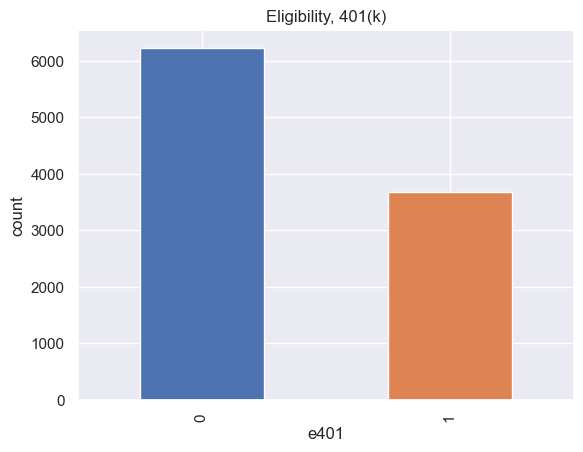

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
colors = sns.color_palette()
data['e401'].value_counts().plot(kind='bar', color=colors)
plt.title('Eligibility, 401(k)')
plt.xlabel('e401')
_ = plt.ylabel('count')

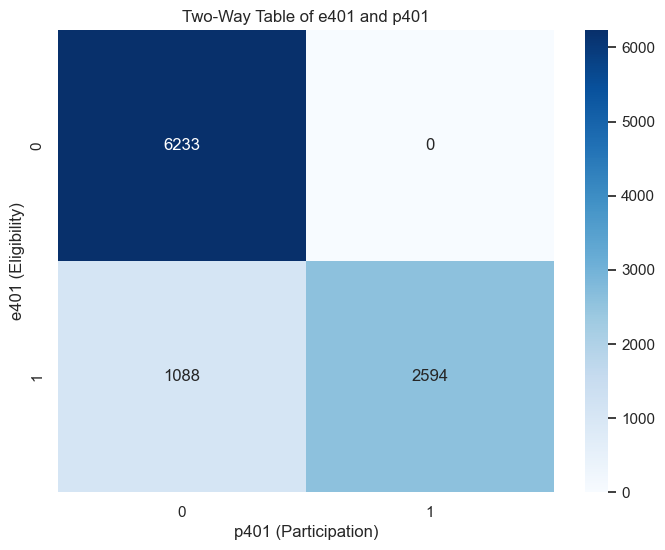

In [13]:
# Create a two-way table (contingency table)
contingency_table = pd.crosstab(data['e401'], data['p401'])

# Plot the two-way table
plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues')
plt.title('Two-Way Table of e401 and p401')
plt.xlabel('p401 (Participation)')
plt.ylabel('e401 (Eligibility)')
plt.show()

### Differences in means

In [14]:
# Group the data by 401(k) participation status (0 or 1)
mean_wealth_by_participation = data.groupby('p401')['net_tfa'].mean()

# Calculate the difference: Mean(net_tfa | p401=1) - Mean(net_tfa | p401=0)
naive_participation_effect = mean_wealth_by_participation.diff().iloc[1]

print(f"Naive Difference in Means (Participation): {naive_participation_effect}")


# Group the data by 401(k) participation status (0 or 1)
mean_wealth_by_participation = data.groupby('e401')['net_tfa'].mean()

# Calculate the difference: Mean(net_tfa | p401=1) - Mean(net_tfa | p401=0)
naive_participation_effect = mean_wealth_by_participation.diff().iloc[1]

print(f"Naive Difference in Means (Eligibility): {naive_participation_effect}")

Naive Difference in Means (Participation): 27371.58340367488
Naive Difference in Means (Eligibility): 19559.344749778058


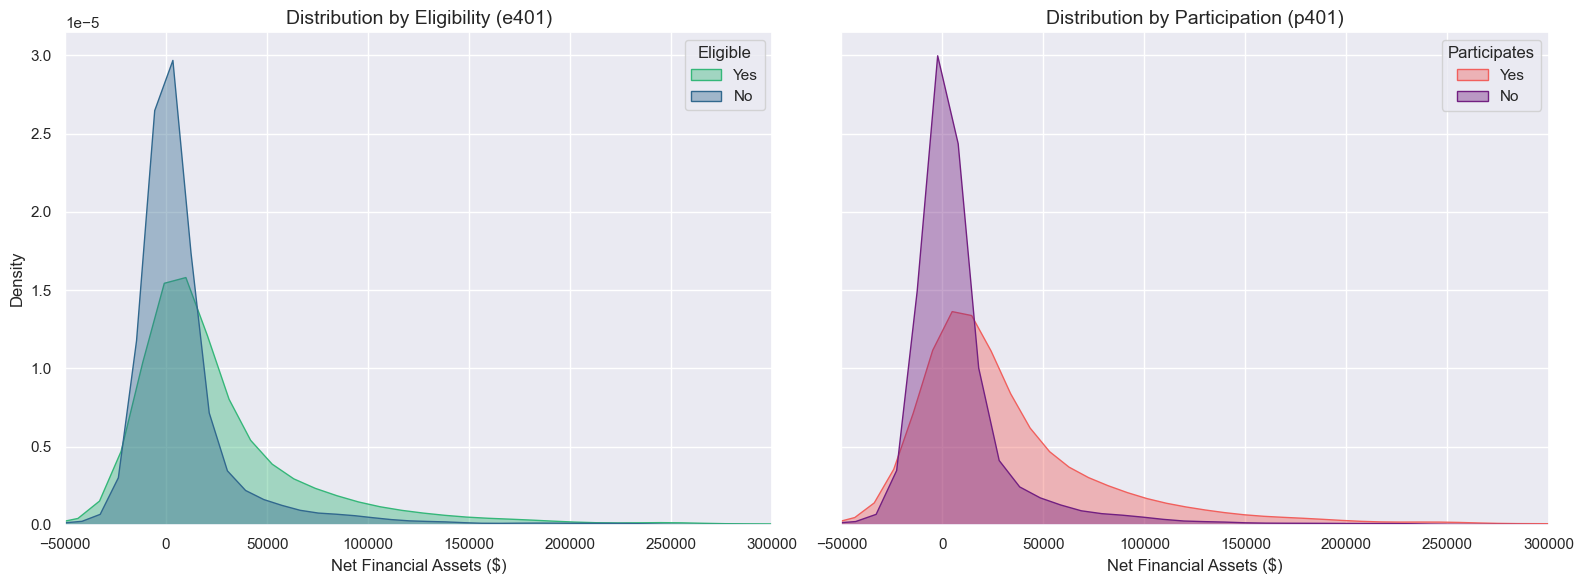

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress the FutureWarnings for a clean presentation
warnings.simplefilter(action='ignore', category=FutureWarning)

# Create the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# 1. Plot for Eligibility (The Instrument Z)
sns.kdeplot(
    data=data, x="net_tfa", hue="e401", fill=True, ax=axes[0], 
    palette="viridis", common_norm=False, alpha=0.4
)
axes[0].set_title("Distribution by Eligibility (e401)", fontsize=14)
axes[0].set_xlabel("Net Financial Assets ($)")
axes[0].legend(title="Eligible", labels=['Yes', 'No'])

# 2. Plot for Participation (The Treatment D)
sns.kdeplot(
    data=data, x="net_tfa", hue="p401", fill=True, ax=axes[1], 
    palette="magma", common_norm=False, alpha=0.4
)
axes[1].set_title("Distribution by Participation (p401)", fontsize=14)
axes[1].set_xlabel("Net Financial Assets ($)")
axes[1].legend(title="Participates", labels=['Yes', 'No'])

# Focus on the bulk of the data (ignoring extreme outliers for better visualization)
for ax in axes:
    ax.set_xlim(-50000, 300000)

plt.tight_layout()
plt.show()

## 5. Thr First Estimand: ATE of Eligility on Net Financial Asset

The causal effect of offering eligibility ($Z$) on the outcome ($Y$), since $Z$ is exogenous conditional on covariates $X$.

### 5.1 Regression Adjustment Estimator

$$\tau(x) = \mu(Z_i=1,X_i=x) - \mu(Z_i=0,X_i=x)$$ ATE is therefore $$\tau = \int \tau(x)dF(x)$$ where $F(x)$ is the cdf of $x$.



#### 5.1.1 Linear Regression

Assuming $$\mu(Z_i=1,X_i=x) = \mu(Z_i=0,X_i=x) = Z_i \alpha + X_i \beta$$ 

In [16]:
import statsmodels.api as sm
features_base = ['age', 'inc', 'educ', 'fsize', 'marr',
                 'twoearn', 'db', 'pira', 'hown']
feature = data[features_base]
X = pd.concat([feature, data[['e401']]], axis=1)
Y = data['net_tfa']
X_cons = sm.add_constant(X)
model = sm.OLS(Y,X_cons)
results = model.fit()
print(results.summary())
print('ATE：',results.params.iloc[[-1]])

                            OLS Regression Results                            
Dep. Variable:                net_tfa   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     297.8
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        04:39:36   Log-Likelihood:            -1.2242e+05
No. Observations:                9915   AIC:                         2.449e+05
Df Residuals:                    9904   BIC:                         2.449e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.291e+04   4276.223     -7.695      0.0

#### 5.1.2 Polynomial Regression


Approximating $$g(X) \approx \beta_0 + \sum_{j=1}^{p} \beta_j x_j + \sum_{j=1}^{p} \sum_{k=j}^{p} \beta_{jk} x_j x_k + \sum_{j=1}^{p} \sum_{k=j}^{p} \sum_{m=k}^{p} \beta_{jkm} x_j x_k x_m + \cdots$$

The corresponding regression model：$$Y_i=D_i \alpha + \beta_0 + \sum_{j=1}^{p} \beta_j x_{ij} + \sum_{j=1}^{p} \sum_{k=j}^{p} \beta_{jk} x_{ij} x_{ik} + \epsilon_i$$

In [17]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3, include_bias=True, interaction_only=False) 
feature_poly = poly.fit_transform(feature)
feature_names = poly.get_feature_names_out(input_features=feature.columns)
feature_poly = pd.DataFrame(feature_poly, columns=feature_names)
X_poly = pd.concat([feature_poly, data[['e401']]], axis=1)

model = sm.OLS(Y,X_poly)
results_ols = model.fit()
print(results_ols.summary())
print('ATE：',results_ols.params.iloc[[-1]])

                            OLS Regression Results                            
Dep. Variable:                net_tfa   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     78.75
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        04:39:38   Log-Likelihood:            -1.2157e+05
No. Observations:                9915   AIC:                         2.433e+05
Df Residuals:                    9846   BIC:                         2.438e+05
Df Model:                          68                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
1                     79.5268     43

#### 5.1.3 Partial Linear Model

$$Y_i = Z_i \alpha + g(X_i) + \epsilon_i$$ 

### The Approximate Sparsity Assumption

Consider an example where we approximate the unknown function $g(X_i)$ using high-order polynomials. Let $W_i$ represent the resulting vector of feature variables. The dimension of this vector, $k$, can be very large—potentially much larger than the sample size—which typically makes standard estimation difficult. 

However, it is often the case that not all variables in $W_i$ are useful for approximating $g(X_i)$. In these scenarios, we can employ machine learning variable selection methods to identify the most relevant predictors and achieve an "optimal" approximation.

#### Formalizing the Mapping
Generalizing this logic, we define a feature mapping $T: X_i \rightarrow W_i$ that transforms a $p$-dimensional vector space into a $k$-dimensional space, where $k \gg p$. This results in the following representation:
$$g(X_i) = W_i \theta + r_i$$
where $r_i$ represents the **approximation error**.

#### The Approximate Sparsity Assumption
The **Approximate Sparsity Assumption** states that the number of non-zero coefficients $s$ in the vector $\theta$ satisfies $s < k$. Crucially:
1. We do not know a priori which specific coefficients are non-zero.
2. As the dataset grows, we can increase the model complexity (by increasing $k$) to reduce the approximation error. 
3. Consequently, the error $r_i$ vanishes as the sample size $n \rightarrow \infty$.

#### Practical Application
Under this assumption, we can utilize machine learning algorithms designed for variable selection, such as **LASSO**. These algorithms identify the $s$ variables with non-zero coefficients, effectively solving the "curse of dimensionality" and addressing multi-collinearity issues inherent in high-dimensional feature spaces.

### **Naive Variable Selection**

First, let us consider the following **Naive Variable Selection Algorithm**: we define a feature mapping to obtain the vector $W_i$, and then use LASSO to estimate the linear regression model:

$$Y_i = D_i \alpha + W_i \theta + U_i$$

Below is the code implementation for this algorithm. In this specific setup, the feature mapping is constructed using **third-order polynomials** (cubic terms) of the original features:

In [18]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
poly = PolynomialFeatures(degree=4, include_bias=True, interaction_only=False) 
feature_poly = poly.fit_transform(feature)
feature_names = poly.get_feature_names_out(input_features=feature.columns)
feature_poly = standard_scaler.fit_transform(feature_poly)
feature_poly = pd.DataFrame(feature_poly, columns=feature_names)
X_poly = pd.concat([feature_poly, data[['e401']]], axis=1)

reg = LassoCV(cv=3, random_state=0, max_iter=1000, tol=0.01).fit(X_poly, Y)
print("Naive Lasso coeffs：", reg.coef_)
print('ATE：',reg.coef_[-1])

Naive Lasso coeffs： [ 0.00000000e+00  0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -1.26745603e+02  0.00000000e+00  0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -0.00000000e+00  0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  0.00000000e+00  5.81274168e+03  0.00000000e+00  0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  0.00000000e+00  0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00  0.00000000e+00
 -0.00000000e+00 -0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00  0.00000000e+00 -0.00000000e+00  0.00000000e+00
  1.22241360e+03  0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -0.0

### **Naive ML Estimator**

##### Prompt: One-Step Naive MLP Estimator for Partial Linear Models

**Task:**
Please provide a Python implementation of a **One-Step Naive ML Estimator** for the partially linear model to demonstrate the regularization bias of the estimator:
$$Y_i = Z_i \alpha + g(X_i) + U_i$$

**Technical Requirements:**

1. **Architecture Definition:**
   - Create a Neural Network (using PyTorch or Keras) that takes both the treatment variable ($Z$) and the vector of covariates ($X$) as inputs.
   - The term $Z_i \alpha$ must be modeled as a **linear skip-connection**: a single trainable weight with no activation and no bias.
   - The nuisance function $g(X_i)$ should be modeled as a standard **Multi-Layer Perceptron (MLP)** (e.g., 2-3 hidden layers with ReLU activations).
   - The final output is the sum of these two components.

2. **Joint Optimization:**
   - The model must be trained in a single stage by minimizing the global MSE loss function:
     $$\min_{\alpha, \mathbf{w}} \frac{1}{n} \sum_{i=1}^n (Y_i - Z_i \alpha - \text{NN}(X_i; \mathbf{w}))^2$$
   - Ensure the structural parameter $\alpha$ is easily extractable after training.

3. **Code Implementation:**
   - Provide a clean, modular Python script.
   - Include a synthetic data generation step where $X$ and $Z$ are correlated (to create the confounding) so the bias can be demonstrated.
   - Include standard pre-processing steps (e.g., scaling) necessary for Neural Network convergence.

4. **The "Teachable Moment" Explanation:**
   - Provide a theoretical explanation for why this joint minimization leads to a biased $\hat{\alpha}$.
   - Focus on the "assignment problem": discuss how, during backpropagation, the flexible MLP $g(X)$ might "attribute" variation in $Y$ that actually stems from $Z$ to itself because $X$ and $Z$ are correlated.
   - Explain why this demonstrates a breakdown in the identification of the causal parameter due to the lack of Neyman Orthogonality.


In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


class PartialLinearNN(nn.Module):
    """
    Y_hat = Z alpha + g_theta(X), where g_theta is an MLP.
    alpha is a trainable linear coefficient vector.
    """
    def __init__(self, x_dim: int, z_dim: int, hidden=(128, 64), dropout=0.0):
        super().__init__()

        layers = []
        in_dim = x_dim
        for h in hidden:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.g = nn.Sequential(*layers)

        # Linear part for Z: alpha (no intercept by default; add a column of ones to Z if desired)
        self.alpha = nn.Parameter(torch.zeros(z_dim, 1))

    def forward(self, x, z):
        # x: (n, x_dim), z: (n, z_dim)
        g_x = self.g(x)                 # (n, 1)
        lin = z @ self.alpha            # (n, 1)
        return lin + g_x                # (n, 1)


def standardize(train: np.ndarray, test: np.ndarray, eps: float = 1e-8):
    mu = train.mean(axis=0, keepdims=True)
    sd = train.std(axis=0, keepdims=True)
    sd = np.where(sd < eps, 1.0, sd)
    return (train - mu) / sd, (test - mu) / sd, mu, sd


@torch.no_grad()
def predict(model, X, Z, device):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    Z_t = torch.tensor(Z, dtype=torch.float32, device=device)
    yhat = model(X_t, Z_t).cpu().numpy().reshape(-1)
    return yhat


def fit_naive_plnn(
    Y: np.ndarray,
    X: np.ndarray,
    Z: np.ndarray,
    *,
    hidden=(128, 64),
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=256,
    epochs=200,
    dropout=0.0,
    val_split=0.2,
    seed=123,
    device=None,
    verbose=True,
):
    """
    Naive ML estimator:
      minimize mean((Y - (Z alpha + NN(X)))^2) over alpha and NN parameters.

    Returns:
      model, alpha_hat (numpy), training history
    """
    assert Y.ndim == 1
    assert X.ndim == 2 and Z.ndim == 2
    n = Y.shape[0]
    assert X.shape[0] == n and Z.shape[0] == n

    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_val = int(np.floor(val_split * n))
    val_idx = idx[:n_val]
    tr_idx = idx[n_val:]

    # Split
    Y_tr, Y_val = Y[tr_idx], Y[val_idx]
    X_tr, X_val = X[tr_idx], X[val_idx]
    Z_tr, Z_val = Z[tr_idx], Z[val_idx]

    # Standardize X and Z (important for NN training; keep alpha interpretable only if you unscale later)
    X_tr_s, X_val_s, X_mu, X_sd = standardize(X_tr, X_val)
    Z_tr_s, Z_val_s, Z_mu, Z_sd = standardize(Z_tr, Z_val)

    # Torch tensors
    Xtr_t = torch.tensor(X_tr_s, dtype=torch.float32)
    Ztr_t = torch.tensor(Z_tr_s, dtype=torch.float32)
    Ytr_t = torch.tensor(Y_tr.reshape(-1, 1), dtype=torch.float32)

    Xva_t = torch.tensor(X_val_s, dtype=torch.float32)
    Zva_t = torch.tensor(Z_val_s, dtype=torch.float32)
    Yva_t = torch.tensor(Y_val.reshape(-1, 1), dtype=torch.float32)

    ds = TensorDataset(Xtr_t, Ztr_t, Ytr_t)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = PartialLinearNN(x_dim=X.shape[1], z_dim=Z.shape[1], hidden=hidden, dropout=dropout).to(device)
    loss_fn = nn.MSELoss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = float("inf")
    best_state = None
    history = {"train_mse": [], "val_mse": []}

    for ep in range(1, epochs + 1):
        model.train()
        train_losses = []
        for xb, zb, yb in dl:
            xb, zb, yb = xb.to(device), zb.to(device), yb.to(device)

            opt.zero_grad(set_to_none=True)
            yhat = model(xb, zb)
            loss = loss_fn(yhat, yb)
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            yva_hat = model(Xva_t.to(device), Zva_t.to(device))
            val_loss = loss_fn(yva_hat, Yva_t.to(device)).item()

        tr_mse = float(np.mean(train_losses))
        history["train_mse"].append(tr_mse)
        history["val_mse"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose and (ep % 25 == 0 or ep == 1 or ep == epochs):
            print(f"epoch {ep:4d} | train_mse={tr_mse:.6f} | val_mse={val_loss:.6f}")

    # Restore best
    if best_state is not None:
        model.load_state_dict(best_state)

    # alpha_hat in standardized Z-units
    alpha_hat_std = model.alpha.detach().cpu().numpy().reshape(-1)

    # Convert alpha back to original Z scale (since we standardized Z: Z_s = (Z - mu)/sd)
    # Model uses: Y ≈ (Z_s) alpha_std + g(X_s)
    # So in original Z: (Z - mu)/sd * alpha_std = Z*(alpha_std/sd) - mu*(alpha_std/sd)
    # If you included an intercept in Z, handle separately. Here: no intercept term.
    alpha_hat = alpha_hat_std / Z_sd.reshape(-1)

    out = {
        "model": model,
        "alpha_hat": alpha_hat,
        "alpha_hat_stdZ": alpha_hat_std,
        "scalers": {"X_mu": X_mu, "X_sd": X_sd, "Z_mu": Z_mu, "Z_sd": Z_sd},
        "history": history,
        "device": device,
    }
    return out


# ---------------- Example usage ----------------
if __name__ == "__main__":
    # Fake data example
    n, x_dim, z_dim = 5000, 10, 1
    rng = np.random.default_rng(0)
    X = rng.normal(size=(n, x_dim))
    Z = 0.1 * X[:, :z_dim] + rng.normal(size=(n, z_dim))
    alpha_true = np.array([1.5])
    g_true = np.sin(X[:, 0]) + 0.5 * X[:, 1] ** 2
    Y = Z @ alpha_true + g_true + rng.normal(scale=1.0, size=n)

    res = fit_naive_plnn(Y, X, Z, hidden=(128, 64), epochs=200, lr=1e-3, dropout=0.1, verbose=True)
    print("alpha_hat (original Z scale):", res["alpha_hat"])

epoch    1 | train_mse=4.373804 | val_mse=4.230181
epoch   25 | train_mse=2.254764 | val_mse=2.556949
epoch   50 | train_mse=1.584066 | val_mse=1.877495
epoch   75 | train_mse=1.198720 | val_mse=1.499810
epoch  100 | train_mse=1.007053 | val_mse=1.281318
epoch  125 | train_mse=0.896259 | val_mse=1.190202
epoch  150 | train_mse=0.847244 | val_mse=1.140625
epoch  175 | train_mse=0.788502 | val_mse=1.141097
epoch  200 | train_mse=0.770269 | val_mse=1.142979
alpha_hat (original Z scale): [1.44189689]


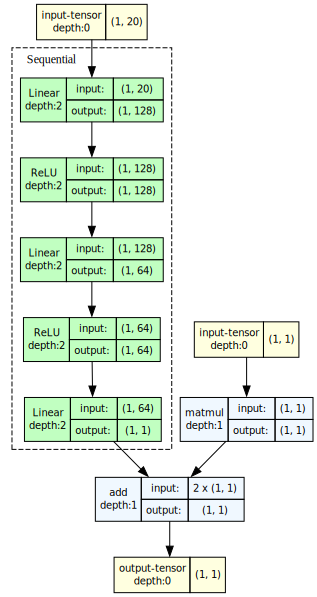

In [5]:
!pip install torchview
from torchview import draw_graph
import torch

# Initialize your model
model = PartialLinearNN(x_dim=20, z_dim=1)

# Generate the graph
# Note: we provide dummy input shapes for both X and Z
model_graph = draw_graph(
    model, 
    input_data=[torch.randn(1, 20), torch.randn(1, 1)],
    expand_nested=True,
    graph_name='PartialLinearNN'
)

# Display in Jupyter/Colab or save to PDF/PNG
model_graph.visual_graph

### Special Case of DML: Double Variable Selection

To estimate the treatment effect $\alpha$ in the presence of high-dimensional controls, we employ the **Post-Double-Selection** method. This approach ensures that we include all controls that are either strong predictors of the outcome or strong predictors of treatment assignment.

### The Three-Step Procedure

1.  **Step 1: Outcome Selection (Linear Lasso)**
    Run a Linear Lasso regression of the outcome $Y$ on the high-dimensional control variables $X$.
    $$\min_{\theta} \frac{1}{n} \sum_{i=1}^n (Y_i - X_i \theta)^2 + \lambda_1 \|\theta\|_1$$
    Let $S_1$ be the set of indices for which the estimated coefficients $\hat{\theta}$ are non-zero.

2.  **Step 2: Treatment Selection (Logistic Lasso)**
    Since the treatment variable $Z$ (e.g., 401(k) eligibility) is binary, we use a Logistic Lasso to model the propensity score $P(Z=1|X)$. The $L_1$ penalty shrinks irrelevant coefficients to zero:
    $$\min_{\gamma} -\frac{1}{n} \sum_{i=1}^n \left[ Z_i \log(\Lambda(X_i \gamma)) + (1-Z_i) \log(1-\Lambda(X_i \gamma)) \right] + \lambda_2 \|\gamma\|_1$$
    where $\Lambda(\cdot)$ is the logistic CDF. Let $S_2$ be the set of indices for which the estimated coefficients $\hat{\gamma}$ are non-zero.

3.  **Step 3: Union and Post-Selection OLS**
    Construct the union of the selected variables: $W = S_1 \cup S_2$. Estimate the treatment effect $\alpha$ by running an Ordinary Least Squares (OLS) regression of $Y$ on $Z$ and the set of controls in $W$:
    $$Y_i = Z_i \alpha + W_i \gamma + \epsilon_i$$

---

### Econometric Intuition: The "Safety Net"
The "Double Selection" framework acts as a safety net against **omitted variable bias**. In high-dimensional settings, a simple "Naive" Lasso (Step 1 only) might drop a covariate that has a small effect on $Y$ but a massive correlation with $Z$. Dropping such a variable leads to traditional omitted variable bias in $\hat{\alpha}$. Step 2 (the Logit Lasso) identifies these "strong confounders," ensuring they are included in the final regression.



### Key Citations
* **Belloni, A., Chernozhukov, V., & Hansen, C. (2014).** "High-Dimensional Methods and Inference on Structural and Treatment Effects." *Journal of Economic Perspectives*, 28(2), 29-50.
* **Belloni, A., Chernozhukov, V., & Hansen, C. (2014).** "Inference on Treatment Effects after Selection amongst High-Dimensional Controls." *The Review of Economic Studies*, 81(2), 608-650.
* **Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., & Robins, J. (2018).** "Double/debiased machine learning for treatment and structural parameters." *The Econometrics Journal*, 21(1), C1-C68.

In [26]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LassoCV, LogisticRegressionCV

import statsmodels.api as sm


def read_data(path, file, sep=",", index_col=0, encoding="utf-8"):
    return pd.read_csv(
        os.path.join(path, file),
        sep=sep,
        index_col=index_col,
        encoding=encoding,
        engine="python",
    )


def feature_mapping(df, features_base, degree=3):
    """
    Build a polynomial dictionary of X and standardize it.
    Note: include_bias=False since we'll add an intercept in the final OLS via statsmodels.
    """
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    scaler = StandardScaler()

    X0 = df[features_base].astype(float)
    X_poly = poly.fit_transform(X0)
    names = poly.get_feature_names_out(input_features=X0.columns)

    X_poly = scaler.fit_transform(X_poly)
    return pd.DataFrame(X_poly, columns=names, index=df.index)


def _selected_from_coef(feature_names, coef, tol=1e-8):
    """
    Robustly pick selected features based on coefficient magnitude.
    Handles:
      - coef shape (p,)
      - coef shape (1,p)
      - coef shape (K,p) (multiclass): uses max abs across classes
    """
    coef = np.asarray(coef)
    if coef.ndim == 1:
        score = np.abs(coef)
    else:
        score = np.max(np.abs(coef), axis=0)

    return [name for name, s in zip(feature_names, score) if s > tol]


def feature_selection_lasso(X, y, k=5, max_iter=5000, tol=1e-4, coef_tol=1e-8):
    """
    LassoCV selection for continuous outcomes.
    """
    feature_names = list(X.columns)
    y = np.asarray(y).reshape(-1)  # ensure 1D

    model = LassoCV(cv=k, random_state=0, max_iter=max_iter, tol=tol).fit(X, y)
    return _selected_from_coef(feature_names, model.coef_, tol=coef_tol), model


def feature_selection_logit_l1(X, y, k=5, max_iter=5000, tol=1e-4, coef_tol=1e-8):
    """
    LogisticRegressionCV with L1 penalty for binary outcomes.
    """
    feature_names = list(X.columns)
    y = np.asarray(y).reshape(-1)  # ensure 1D {0,1}

    model = LogisticRegressionCV(
        cv=k,
        random_state=0,
        penalty="l1",
        solver="liblinear",
        max_iter=max_iter,
        tol=tol,
    ).fit(X, y)

    return _selected_from_coef(feature_names, model.coef_, tol=coef_tol), model


def partial_out(y, W):
    """
    Residualize y on W via least squares:
      y_res = y - W (W'W)^{-1} W' y
    Works for y as (n,) or (n,1) or (n,p).
    """
    y = np.asarray(y)
    if y.ndim == 1:
        y = y.reshape(-1, 1)

    W = np.asarray(W)
    B, *_ = np.linalg.lstsq(W, y, rcond=None)  # solves min ||W B - y||
    y_hat = W @ B
    return (y - y_hat)


def post_double_selection(
    y, d, X_dict,
    *,
    d_is_binary=True,
    k=5,
    max_iter=5000,
    tol=1e-4,
    coef_tol=1e-8,
    robust_se="HC3"
):
    """
    Post-Double Selection (PDS):

    Step 1 (Outcome selection, conditional on D):
      - partial out [1, D] from Y and from X
      - LASSO: y_tilde ~ X_tilde  => S_y

    Step 2 (Treatment selection):
      - if D binary: logit L1: D ~ X => S_d
        (or use LASSO on D as linear probability if you prefer strict linear theory)
      - else: LASSO: D ~ X

    Step 3 (Post-OLS):
      - OLS: Y ~ D + X_{S_y ∪ S_d} + const
    """
    # Align indices and drop missing
    df = pd.concat([y, d, X_dict], axis=1).dropna()
    yv = df[y.name].astype(float).to_numpy()
    dv = df[d.name].astype(float).to_numpy()
    Xv = df[X_dict.columns].astype(float)

    n = len(df)
    W = np.column_stack([np.ones(n), dv])  # [1, D]

    # Step 1: residualize Y and X on [1, D], then lasso select controls
    y_tilde = partial_out(yv, W).reshape(-1)
    X_tilde = partial_out(Xv.to_numpy(), W)  # (n, p)
    X_tilde_df = pd.DataFrame(X_tilde, columns=Xv.columns, index=df.index)

    S_y, lasso_y = feature_selection_lasso(
        X_tilde_df, y_tilde, k=k, max_iter=max_iter, tol=tol, coef_tol=coef_tol
    )

    # Step 2: treatment selection
    if d_is_binary:
        # NOTE: for strict BCH(2014) linear-model assumptions, you can replace this with LASSO on dv.
        S_d, treat_model = feature_selection_logit_l1(
            Xv, (dv > 0.5).astype(int), k=k, max_iter=max_iter, tol=tol, coef_tol=coef_tol
        )
    else:
        S_d, treat_model = feature_selection_lasso(
            Xv, dv, k=k, max_iter=max_iter, tol=tol, coef_tol=coef_tol
        )

    # Union
    S = sorted(set(S_y).union(set(S_d)))

    # Step 3: Post-OLS
    X_post = pd.concat([df[[d.name]], df[S]], axis=1)
    X_post = sm.add_constant(X_post, has_constant="add")

    ols = sm.OLS(df[y.name].astype(float), X_post).fit(cov_type=robust_se)

    return {
        "selected_outcome": S_y,
        "selected_treatment": S_d,
        "selected_union": S,
        "ols_result": ols,
        "alpha_hat": float(ols.params[d.name]),
        "alpha_se": float(ols.bse[d.name]),
    }


# ---------------- Example usage with your variables ----------------
if __name__ == "__main__":
    features_base = ['age','inc','educ','fsize','marr','twoearn','db','pira','hown']
    X_dict = feature_mapping(data, features_base, degree=3)  # high-dim dictionary
    y = data['net_tfa']
    d = data['e401']
    res = post_double_selection(y, d, X_dict, d_is_binary=True)
    print("alpha_hat:", res["alpha_hat"])
    print("alpha_se:", res["alpha_se"])
    print(res["ols_result"].summary())

alpha_hat: 9381.251379140223
alpha_se: 1330.2297743132128
                            OLS Regression Results                            
Dep. Variable:                net_tfa   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     40.53
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:20:39   Log-Likelihood:            -1.2165e+05
No. Observations:                9915   AIC:                         2.434e+05
Df Residuals:                    9865   BIC:                         2.438e+05
Df Model:                          49                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

/opt/conda/lib/python3.10/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 59, but rank is 49
  warnings.warn('covariance of constraints does not have full '



$$
Y = \alpha Z + g_0(X) + U, \qquad \mathbb{E}[U \mid X, Z] = 0
$$


---

# DML via Partialing Out with Sample Splitting

## Key Idea

DML separates the estimation of the causal parameter from the estimation of the nuisance functions.

Define two nuisance functions:

Outcome regression:
$$
g_0(X) = \mathbb{E}[Y \mid X]
$$

Treatment model (propensity score for binary treatment):
$$
m_0(X) = \mathbb{E}[Z \mid X]
$$

The DML estimator first estimates these nuisance functions using machine learning and then **partial-outs their effects**.

Define residualized variables:

$$
\tilde{Y}_i = Y_i - \hat{g}(X_i)
$$

$$
\tilde{Z}_i = Z_i - \hat{m}(X_i)
$$

The treatment effect estimator is obtained from the regression:

$$
\tilde{Y}_i = \alpha \tilde{Z}_i + \varepsilon_i
$$

which yields

$$
\hat{\alpha}_{DML} =
\frac{\sum_i \tilde{Z}_i \tilde{Y}_i}
{\sum_i \tilde{Z}_i^2}
$$

This procedure removes the variation in \(Y\) and \(Z\) that can be explained by \(X\), isolating the causal relationship between the two.

---

# Sample Splitting and Cross-Fitting

A critical component of DML is **sample splitting**.

Flexible machine learning estimators can easily overfit the data.  
If the same sample is used both to estimate the nuisance functions and to estimate \(\alpha\), the residuals may inherit estimation bias.

To avoid this, DML uses **cross-fitting**:

1. Split the data into \(K\) folds.
2. For each fold \(k\):
   - Estimate \(g(X)\) and \(m(X)\) using all other folds.
   - Predict these functions on the held-out fold.
3. Construct residuals using the out-of-sample predictions.
4. Combine all folds to estimate \(\alpha\).

Cross-fitting ensures that nuisance predictions are always **out-of-sample**, which prevents overfitting bias.

---

# Neyman Orthogonality

DML relies on an **orthogonal moment condition**.

Define the score function:

$$
\psi(W; \alpha, \eta)
=
\big(Y - g(X) - \alpha (Z - m(X))\big)(Z - m(X))
$$

where  

$$
\eta = (g, m)
$$

The true parameter satisfies

$$
\mathbb{E}[\psi(W; \alpha_0, \eta_0)] = 0
$$

The key property is **Neyman orthogonality**:

$$
\left.
\frac{\partial}{\partial \eta}
\mathbb{E}[\psi(W; \alpha_0, \eta)]
\right|_{\eta = \eta_0}
= 0
$$

This means that small estimation errors in the nuisance functions affect the estimator of \(\alpha\) only at **second order**.

Consequently, machine learning estimators that converge relatively slowly can still yield **root-\(n\) consistent and asymptotically normal estimates of \(\alpha\)**.

---

# Special Case of DML: Double Variable Selection

A particularly important special case of DML is the **Post-Double-Selection method** proposed by Belloni, Chernozhukov, and Hansen.

This method is designed for high-dimensional linear settings and uses **Lasso regression** to select relevant controls.

---

# The Three-Step Double Selection Procedure

## Step 1: Outcome Selection (Linear Lasso)

Run a Lasso regression of the outcome on the controls:

$$
\min_{\theta}
\frac{1}{n}\sum_{i=1}^{n}(Y_i - X_i\theta)^2
+
\lambda_1 \|\theta\|_1
$$

Let

$$
S_1 = \{j : \hat{\theta}_j \neq 0\}
$$

be the set of variables selected as predictors of the outcome.

---

## Step 2: Treatment Selection (Logistic Lasso)

If the treatment is binary, estimate the propensity score using Logistic Lasso:

$$
\min_{\gamma}
-
\frac{1}{n}
\sum_{i=1}^{n}
\left[
Z_i \log(\Lambda(X_i\gamma))
+
(1-Z_i)\log(1-\Lambda(X_i\gamma))
\right]
+
\lambda_2 \|\gamma\|_1
$$

where  

$$
\Lambda(t) = \frac{1}{1 + e^{-t}}
$$

is the logistic function.

Define

$$
S_2 = \{j : \hat{\gamma}_j \neq 0\}
$$

as the set of predictors of treatment assignment.

---

## Step 3: Union and Post-Selection OLS

Construct the union of selected variables:

$$
W = S_1 \cup S_2
$$

Estimate the treatment effect using OLS:

$$
Y_i = Z_i \alpha + W_i \gamma + \epsilon_i
$$

The coefficient \(\hat{\alpha}\) provides the estimate of the causal effect.

---

# Econometric Intuition: The "Safety Net"

The double selection method acts as a **safety net against omitted variable bias**.

A naive Lasso regression of \(Y\) on \(X\) may drop variables that have only a weak effect on \(Y\) but are highly correlated with the treatment \(Z\).  
Dropping such variables would bias the treatment effect estimate.

The double selection procedure protects against this by including variables that predict:

1. the outcome \(Y\), and  
2. the treatment \(Z\).

By taking the **union of both sets of variables**, the method ensures that important confounders are retained in the final regression.

---

# Relationship Between Double Selection and DML

Double selection can be interpreted as a **special case of the DML partialing-out framework**.

The Frisch–Waugh–Lovell theorem shows that the coefficient \(\alpha\) from

$$
Y = \alpha Z + W\gamma + \varepsilon
$$

is equivalent to the regression:

1. Regress \(Y\) on \(W\) and compute residuals
2. Regress \(Z\) on \(W\) and compute residuals
3. Regress the residualized \(Y\) on the residualized \(Z\)

This is exactly the **partialing-out procedure** used in DML.

Thus:

- **DML** is the general framework that allows arbitrary machine learning methods for nuisance estimation.
- **Post-Double-Selection** is a sparse linear implementation of the same orthogonalization idea.

---

# Why DML Solves the Assignment Problem

In naive machine learning estimation of

$$
Y = Z\alpha + g(X)
$$

a flexible model for \(g(X)\) may absorb variation that actually belongs to the treatment term \(Z\alpha\), especially when \(Z\) is correlated with \(X\).

This creates a **regularization bias**: the model attributes part of the treatment effect to the nuisance function.

DML prevents this by removing predictable components of both variables:

$$
\tilde{Y} = Y - \hat{g}(X)
$$

$$
\tilde{Z} = Z - \hat{m}(X)
$$

The estimator then uses only the variation in \(Z\) that cannot be predicted by \(X\).

This isolates the causal signal and prevents the nuisance model from “stealing” the treatment effect.

---

# Key References

**Belloni, A., Chernozhukov, V., & Hansen, C. (2014).**  
High-Dimensional Methods and Inference on Structural and Treatment Effects.  
*Journal of Economic Perspectives*, 28(2), 29–50.

**Belloni, A., Chernozhukov, V., & Hansen, C. (2014).**  
Inference on Treatment Effects after Selection among High-Dimensional Controls.  
*Review of Economic Studies*, 81(2), 608–650.

**Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., & Robins, J. (2018).**  
Double/Debiased Machine Learning for Treatment and Structural Parameters.  
*Econometrics Journal*, 21(1), C1–C68.

# General DML Implemented by Partialing Out

## Promt for Generating Code

**Task:**
Write a **complete Python implementation of Double Machine Learning (DML)** for the **Partially Linear Regression (PLR) model** using the **partialing-out estimator with cross-fitting**.

---

## Econometric Model

Assume the partially linear model:

$$
Y = \alpha D + g(X) + U, \qquad E[U|X,D]=0
$$

where

* (Y) is the outcome
* (D) is the treatment variable (binary or continuous)
* (X) is a high-dimensional vector of controls
* (g(X)) is an unknown nuisance function

The goal is to estimate the causal parameter ( \alpha ).

---

## Algorithm Requirements

Implement **Double Machine Learning via partialing-out with sample splitting**:

1. Estimate nuisance functions

$$
g(X) = E[Y|X]
$$

$$
m(X) = E[D|X]
$$

using machine learning.

2. Use **K-fold cross-fitting**:

   * Train nuisance models on (K-1) folds
   * Predict on the held-out fold
   * Assemble out-of-sample predictions.

3. Residualize variables:

$$
\tilde{Y}_i = Y_i - \hat g(X_i)
$$

$$
\tilde{D}_i = D_i - \hat m(X_i)
$$

4. Estimate the treatment effect

$$
\hat{\alpha} =
\frac{\frac{1}{n}\sum \tilde{D}_i\tilde{Y}_i}
{\frac{1}{n}\sum \tilde{D}_i^2}
$$

---

## Statistical Requirements

The implementation must include:

* **Orthogonal score based standard errors**

$$
\psi_i = (\tilde{Y}_i - \hat\alpha \tilde{D}_i)\tilde{D}_i
$$

$$
Var(\hat\alpha)=
\frac{1}{n}
\frac{\frac{1}{n}\sum \psi_i^2}
{\left(\frac{1}{n}\sum \tilde{D}_i^2\right)^2}
$$

* 95% confidence intervals
* two-sided p-value

---

## Machine Learning Requirements

The nuisance learners should be configurable and support:

* Lasso / Logistic Lasso
* Random Forest
* Neural Network (MLP)

Each learner should optionally support **hyperparameter tuning via cross-validation**.

---

## Engineering Requirements

The code must:

* Allow configurable parameters:

  * number of folds
  * ML algorithms
  * hyperparameter tuning
  * polynomial feature expansion

---

## Output

The function should return:

* estimated treatment effect $\hat\alpha$
* standard error
* z-statistic
* p-value
* confidence interval
* nuisance predictions $\hat g(X)$, $\hat m(X)$

---

## Deliverables

Provide:

1. Clean modular Python code
2. Clear comments explaining each step of the DML algorithm
3. Example usage on a dataset

---

## Reference

Follow the methodology of

Chernozhukov et al. (2018)
“Double/Debiased Machine Learning for Treatment and Structural Parameters”
Econometrics Journal.


In [2]:
"""
General DML (Double / Debiased Machine Learning) for the Partially Linear Model (PLR)
via partialing-out + sample splitting (cross-fitting).

Model:
    Y = alpha * D + g(X) + U,   E[U | X, D] = 0

Algorithm (PLR / partialing-out):
  1) Cross-fit nuisance learners:
        g_hat(x) ≈ E[Y|X=x]
        m_hat(x) ≈ E[D|X=x]   (propensity score if D binary)
  2) Residualize:
        y_tilde = Y - g_hat(X)
        d_tilde = D - m_hat(X)
  3) Estimate:
        alpha_hat = mean(d_tilde * y_tilde) / mean(d_tilde^2)
     with score-based robust SE.

Supports nuisance ML methods:
  - "lasso" (LassoCV / LogisticRegressionCV)
  - "rf"    (RandomForest) + optional hyperparameter tuning via RandomizedSearchCV
  - "mlp"   (sklearn MLP)  + optional hyperparameter tuning via RandomizedSearchCV

Important notes:
  - For binary D, uses StratifiedKFold (recommended).
  - Optional propensity clipping to avoid extreme predicted probabilities.
  - Any preprocessing that learns from data (scaling) is done inside fold training only.
"""

import os
import numpy as np
import pandas as pd

from math import erf, sqrt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier


# ---------------------------------------------------------
# Data utilities (optional)
# ---------------------------------------------------------

def read_data(path, file, sep=",", index_col=0, encoding="utf-8"):
    return pd.read_csv(
        os.path.join(path, file),
        sep=sep,
        index_col=index_col,
        encoding=encoding,
        engine="python",
    )


def feature_mapping(df, features_base, degree=3, scale=False):
    """
    Polynomial feature dictionary.
    NOTE: scaling here (scale=True) would leak information across folds in strict DML usage.
    Prefer scale=False and let the ML pipelines scale within each fold.
    """
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X0 = df[features_base].astype(float)
    X_poly = poly.fit_transform(X0)
    names = poly.get_feature_names_out(input_features=X0.columns)

    if scale:
        # Not recommended for strict sample-splitting DML
        scaler = StandardScaler()
        X_poly = scaler.fit_transform(X_poly)

    return pd.DataFrame(X_poly, columns=names, index=df.index)


# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------

def _norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))


def _two_sided_p_value_from_z(z: float) -> float:
    return 2.0 * (1.0 - _norm_cdf(abs(z)))


def _to_binary_labels(d: np.ndarray) -> np.ndarray:
    """
    Convert a treatment array into 0/1 labels robustly.
    - If exactly two unique values exist, map min->0, max->1.
    - Else fall back to threshold at 0.5.
    """
    d = np.asarray(d)
    u = np.unique(d[~np.isnan(d)])
    if u.size == 2:
        hi = u.max()
        return (d == hi).astype(int)
    return (d > 0.5).astype(int)


def _default_param_distributions(model_type: str, is_classifier: bool):
    """
    Default hyperparameter search spaces for RandomizedSearchCV.
    Keys assume a Pipeline step named "model".
    """
    if model_type == "rf":
        return {
            "model__n_estimators": [200, 400, 800],
            "model__max_depth": [None, 5, 10, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 5, 10],
            "model__max_features": ["sqrt", "log2", 0.3, 0.5, 1.0],
        }

    if model_type == "mlp":
        # Keep the search space modest; MLP tuning can be expensive.
        return {
            "model__hidden_layer_sizes": [(64, 64), (128, 64), (256, 128)],
            "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
            "model__learning_rate_init": [2e-4, 5e-4, 1e-3, 2e-3],
            "model__batch_size": [64, 128, 256],
        }

    raise ValueError(f"No default param distributions for model_type={model_type!r}")


def build_nuisance_learner(
    model_type: str,
    *,
    is_classifier: bool,
    poly_degree: int | None = None,
    tune: bool = False,
    inner_cv: int = 3,
    n_iter: int = 20,
    random_state: int = 0,
    n_jobs: int = -1,
    param_distributions: dict | None = None,
):
    """
    Build a nuisance learner for g(X)=E[Y|X] (regression) or m(X)=E[D|X] (regression/classification).

    If tune=True and model_type in {"rf","mlp"}, wraps the pipeline in RandomizedSearchCV.
    For model_type=="lasso", uses built-in CV estimators (LassoCV / LogisticRegressionCV).
    """

    # Feature expansion step (optional)
    if poly_degree is None or poly_degree <= 1:
        poly_step = "passthrough"
    else:
        poly_step = PolynomialFeatures(degree=poly_degree, include_bias=False)

    # Choose base model
    if model_type == "lasso":
        if is_classifier:
            # Logistic L1 with CV over C (inverse regularization)
            base_model = LogisticRegressionCV(
                Cs=10,
                cv=5,
                penalty="l1",
                solver="saga",           # scalable for high-dim
                scoring="neg_log_loss",
                max_iter=5000,
                tol=1e-4,
                n_jobs=n_jobs,
                random_state=random_state,
                refit=True,
            )
        else:
            base_model = LassoCV(
                cv=5,
                n_alphas=50,
                max_iter=5000,
                tol=1e-4,
                random_state=random_state,
            )

        # Scaling is important for Lasso / logistic-lasso
        pipe = Pipeline([
            ("poly", poly_step),
            ("scaler", StandardScaler()),
            ("model", base_model),
        ])

        # LassoCV/LogisticRegressionCV already do CV; no extra wrapper needed.
        return pipe

    elif model_type == "rf":
        if is_classifier:
            base_model = RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=5,
                n_jobs=n_jobs,
                random_state=random_state,
            )
        else:
            base_model = RandomForestRegressor(
                n_estimators=400,
                min_samples_leaf=5,
                n_jobs=n_jobs,
                random_state=random_state,
            )

        # RF does not need scaling; keep scaler passthrough for speed/clarity.
        pipe = Pipeline([
            ("poly", poly_step),
            ("scaler", "passthrough"),
            ("model", base_model),
        ])

        if not tune:
            return pipe

        if param_distributions is None:
            param_distributions = _default_param_distributions("rf", is_classifier=is_classifier)

        scoring = "neg_log_loss" if is_classifier else "neg_mean_squared_error"
        return RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_distributions,
            n_iter=n_iter,
            cv=inner_cv,
            scoring=scoring,
            random_state=random_state,
            n_jobs=n_jobs,
            refit=True,
            error_score="raise",
        )

    elif model_type == "mlp":
        if is_classifier:
            base_model = MLPClassifier(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                batch_size=128,
                learning_rate_init=1e-3,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
                max_iter=2000,
                random_state=random_state,
            )
        else:
            base_model = MLPRegressor(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                batch_size=128,
                learning_rate_init=1e-3,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
                max_iter=2000,
                random_state=random_state,
            )

        # MLP benefits from scaling
        pipe = Pipeline([
            ("poly", poly_step),
            ("scaler", StandardScaler()),
            ("model", base_model),
        ])

        if not tune:
            return pipe

        if param_distributions is None:
            param_distributions = _default_param_distributions("mlp", is_classifier=is_classifier)

        scoring = "neg_log_loss" if is_classifier else "neg_mean_squared_error"
        return RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_distributions,
            n_iter=n_iter,
            cv=inner_cv,
            scoring=scoring,
            random_state=random_state,
            n_jobs=n_jobs,
            refit=True,
            error_score="raise",
        )

    else:
        raise ValueError(f"Unknown model_type={model_type!r}")


# ---------------------------------------------------------
# DML PLR: partialing-out with cross-fitting
# ---------------------------------------------------------

def dml_plr_partialing_out(
    y: pd.Series,
    d: pd.Series,
    X: pd.DataFrame,
    *,
    d_is_binary: bool = True,
    ml_g: str = "rf",
    ml_m: str = "rf",
    # cross-fitting
    n_splits: int = 5,
    random_state: int = 0,
    # optional feature expansion inside folds
    poly_degree: int | None = None,
    # optional tuning (nested CV) for RF/MLP
    tune_g: bool = False,
    tune_m: bool = False,
    inner_cv: int = 3,
    n_iter: int = 20,
    n_jobs: int = -1,
    # stability
    clip_pscore: float | None = 1e-6,
    # outputs
    return_nuisance_predictions: bool = True,
    return_fold_params: bool = True,
):
    """
    DML for PLR via partialing-out with cross-fitting.

    Returns:
      dict with alpha_hat, alpha_se (score-based), CI, p-value,
      and optionally nuisance predictions and per-fold best params (if tuned).
    """

    # Ensure names exist (avoid y.name is None issues)
    y_name = y.name if y.name is not None else "Y"
    d_name = d.name if d.name is not None else "D"
    y = y.rename(y_name)
    d = d.rename(d_name)

    # Align indices and drop missing
    df = pd.concat([y, d, X], axis=1).dropna()
    Y = df[y_name].astype(float).to_numpy()
    D = df[d_name].astype(float).to_numpy()
    Xv = df[X.columns].astype(float).to_numpy()

    n = len(df)
    if n < max(50, n_splits * 10):
        # not a hard requirement, but warns about unstable folds/tuning
        pass

    # For binary D: stratified splitting improves stability
    if d_is_binary:
        D_bin = _to_binary_labels(D)
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        split_iter = splitter.split(Xv, D_bin)
    else:
        D_bin = None
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        split_iter = splitter.split(Xv)

    g_hat = np.empty(n, dtype=float)
    m_hat = np.empty(n, dtype=float)

    g_best_params = []
    m_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(split_iter, start=1):
        X_tr, X_te = Xv[tr_idx], Xv[te_idx]
        Y_tr = Y[tr_idx]
        D_tr = D[tr_idx]

        # ----- outcome nuisance: g(x)=E[Y|X=x] -----
        g_model = build_nuisance_learner(
            ml_g,
            is_classifier=False,
            poly_degree=poly_degree,
            tune=tune_g,
            inner_cv=inner_cv,
            n_iter=n_iter,
            random_state=random_state + 1000 * fold,
            n_jobs=n_jobs,
        )
        g_model.fit(X_tr, Y_tr)
        g_hat[te_idx] = g_model.predict(X_te)

        if return_fold_params and hasattr(g_model, "best_params_"):
            g_best_params.append(g_model.best_params_)
        elif return_fold_params:
            g_best_params.append(None)

        # ----- treatment nuisance: m(x)=E[D|X=x] -----
        if d_is_binary:
            m_model = build_nuisance_learner(
                ml_m,
                is_classifier=True,
                poly_degree=poly_degree,
                tune=tune_m,
                inner_cv=inner_cv,
                n_iter=n_iter,
                random_state=random_state + 2000 * fold,
                n_jobs=n_jobs,
            )
            m_model.fit(X_tr, _to_binary_labels(D_tr))
            p = m_model.predict_proba(X_te)[:, 1]
            if clip_pscore is not None:
                p = np.clip(p, clip_pscore, 1.0 - clip_pscore)
            m_hat[te_idx] = p

            if return_fold_params and hasattr(m_model, "best_params_"):
                m_best_params.append(m_model.best_params_)
            elif return_fold_params:
                m_best_params.append(None)

        else:
            m_model = build_nuisance_learner(
                ml_m,
                is_classifier=False,
                poly_degree=poly_degree,
                tune=tune_m,
                inner_cv=inner_cv,
                n_iter=n_iter,
                random_state=random_state + 2000 * fold,
                n_jobs=n_jobs,
            )
            m_model.fit(X_tr, D_tr)
            m_hat[te_idx] = m_model.predict(X_te)

            if return_fold_params and hasattr(m_model, "best_params_"):
                m_best_params.append(m_model.best_params_)
            elif return_fold_params:
                m_best_params.append(None)

    # Residualize (partial-out)
    y_tilde = Y - g_hat
    d_tilde = D - m_hat

    # DML point estimate (no-intercept residual regression)
    denom = float(np.mean(d_tilde ** 2))
    if denom <= 1e-20:
        raise ValueError(
            "Residualized treatment has (near) zero variance. "
            "Check overlap / propensity model / clipping / data quality."
        )

    alpha_hat = float(np.mean(d_tilde * y_tilde) / denom)

    # Score-based robust SE for orthogonal score:
    # psi_i = (y_tilde - alpha_hat d_tilde) * d_tilde
    psi = (y_tilde - alpha_hat * d_tilde) * d_tilde
    var_hat = (float(np.mean(psi ** 2)) / (denom ** 2)) / n
    alpha_se = float(np.sqrt(var_hat))

    z = alpha_hat / alpha_se if alpha_se > 0 else np.inf
    p_value = float(_two_sided_p_value_from_z(z))

    ci95 = (alpha_hat - 1.96 * alpha_se, alpha_hat + 1.96 * alpha_se)

    out = {
        "n_obs": int(n),
        "alpha_hat": alpha_hat,
        "alpha_se": alpha_se,
        "z_stat": float(z),
        "p_value": p_value,
        "ci95": (float(ci95[0]), float(ci95[1])),
        "ml_g": ml_g,
        "ml_m": ml_m,
        "tune_g": bool(tune_g),
        "tune_m": bool(tune_m),
        "n_splits": int(n_splits),
        "poly_degree": None if poly_degree is None else int(poly_degree),
    }

    if return_nuisance_predictions:
        out.update({
            "g_hat": g_hat,
            "m_hat": m_hat,
            "y_tilde": y_tilde,
            "d_tilde": d_tilde,
        })

    if return_fold_params:
        out.update({
            "g_best_params_by_fold": g_best_params,
            "m_best_params_by_fold": m_best_params,
        })

    if d_is_binary:
        out.update({
            "propensity_min": float(np.min(m_hat)),
            "propensity_max": float(np.max(m_hat)),
            "propensity_mean": float(np.mean(m_hat)),
        })

    return out


# ---------------------------------------------------------
# Example usage
# ---------------------------------------------------------
if __name__ == "__main__":
    # Example: assuming you already have a pandas DataFrame called `data`
    # with outcome 'net_tfa', treatment 'e401', and controls listed below.

    # features_base = ['age','inc','educ','fsize','marr','twoearn','db','pira','hown']
    # y = data['net_tfa']
    # d = data['e401']
    # X = data[features_base]

    # Option A (recommended): let DML create polynomial features inside folds
    # res = dml_plr_partialing_out(
    #     y, d, X,
    #     d_is_binary=True,
    #     ml_g="rf",
    #     ml_m="rf",
    #     n_splits=5,
    #     poly_degree=3,
    #     tune_g=True,     # enables RandomizedSearchCV for RF/MLP (lasso already CV's)
    #     tune_m=True,
    #     inner_cv=3,
    #     n_iter=20,
    #     clip_pscore=1e-6,
    # )
    # print("alpha_hat:", res["alpha_hat"])
    # print("alpha_se :", res["alpha_se"])
    # print("ci95     :", res["ci95"])
    # print("p_value  :", res["p_value"])
    # print("propensity range:", res.get("propensity_min"), res.get("propensity_max"))

    # Option B: build a polynomial dictionary externally (no scaling), then set poly_degree=None
    # X_dict = feature_mapping(data, features_base, degree=3, scale=False)
    # res = dml_plr_partialing_out(
    #     y, d, X_dict,
    #     d_is_binary=True,
    #     ml_g="lasso",
    #     ml_m="lasso",
    #     n_splits=5,
    #     poly_degree=None,
    # )
    # print("alpha_hat:", res["alpha_hat"])
    pass

# DML for Fully Nonparametric Treatment Effects via AIPW


This note extends Double / Debiased Machine Learning (DML) from the partially linear regression (PLR) model to the **fully nonparametric** case by using the **Augmented Inverse Probability Weighting (AIPW)** estimator and its **Neyman-orthogonal score**.

We consider the standard potential outcomes framework with a binary treatment.

---

## Setup and Target Parameter

Let:

- $Y \in \mathbb{R}$ be the observed outcome  
- $Z \in \{0,1\} $ be a binary treatment  
- $X \in \mathbb{R}^p$ be a (possibly high-dimensional) vector of covariates  
- $(Y(1), Y(0))$ be potential outcomes  

Observed outcome:
$$
Y = Z Y(1) + (1-Z) Y(0).
$$

### Parameter of Interest: ATE

The **Average Treatment Effect (ATE)** is
$$
\tau_0 = \mathbb{E}[Y(1) - Y(0)].
$$

---

## Identification Assumptions

### 1) Unconfoundedness (Selection on Observables)
$$
(Y(1), Y(0)) \perp Z \mid X.
$$

### 2) Overlap (Positivity)
There exists \(\epsilon > 0\) such that
$$
\epsilon < \mathbb{P}(Z=1 \mid X) < 1-\epsilon \quad \text{a.s.}
$$

Under these assumptions:
$$
\tau_0 = \mathbb{E}\big[\mathbb{E}[Y \mid Z=1, X] - \mathbb{E}[Y \mid Z=0, X]\big].
$$

---

## Nuisance Functions

Define the nuisance components:

### Propensity score
$$
e_0(X) = \mathbb{P}(Z=1 \mid X).
$$

### Outcome regressions
$$
\mu_1(X) = \mathbb{E}[Y \mid Z=1, X], \qquad \mu_0(X) = \mathbb{E}[Y \mid Z=0, X].
$$

Collect nuisances as
$$
\eta_0 = (\mu_0, \mu_1, e_0).
$$

---

## AIPW Estimator

The **AIPW** (Augmented Inverse Probability Weighting) estimator can be written in plug-in form as:

$$
\hat\tau_{\text{AIPW}}
=
\frac{1}{n}\sum_{i=1}^n
\left[
\hat\mu_1(X_i) - \hat\mu_0(X_i)
+
\frac{Z_i\,(Y_i - \hat\mu_1(X_i))}{\hat e(X_i)}
-
\frac{(1-Z_i)\,(Y_i - \hat\mu_0(X_i))}{1-\hat e(X_i)}
\right].
$$

### Double Robustness

AIPW is **doubly robust**

---

## Orthogonal Score Function for ATE (AIPW Score)

Let $W=(Y,Z,X)$. Define the AIPW score:

$$
\psi(W; \tau, \eta)
=
\left[
\mu_1(X) - \mu_0(X)
+
\frac{Z\,(Y - \mu_1(X))}{e(X)}
-
\frac{(1-Z)\,(Y - \mu_0(X))}{1-e(X)}
\right]
- \tau.
$$

The target parameter $\tau_0$ satisfies the moment equation:

$$
\mathbb{E}[\psi(W; \tau_0, \eta_0)] = 0.
$$

### Neyman Orthogonality

The score is **Neyman-orthogonal** with respect to nuisance perturbations:

$$
\left.
\frac{\partial}{\partial \eta}
\mathbb{E}[\psi(W; \tau_0, \eta)]
\right|_{\eta=\eta_0}
= 0.
$$

---

## DML Algorithm for AIPW (Cross-Fitted)

DML uses **sample splitting and cross-fitting** to avoid overfitting bias in nuisance estimation.

Let $K \ge 2$ and split indices into folds $I_1, \dots, I_K$.

### Step 0: Initialize
Choose ML estimators for:

- $\mu_1(X)$ using observations with $D=1$
- $\mu_0(X)$ using observations with $D=0$
- $e(X)$ using all observations (classification)

Optionally include hyperparameter tuning (CV) within each training fold.

---

### Step 1: Cross-Fit Nuisance Functions

For each fold $k \in \{1,\dots,K\}$:

- Training set: $I_k^c = \{1,\dots,n\}\setminus I_k$
- Test set: $I_k$

Fit nuisances on $I_k^c$:

Outcome regressions:
$$
\hat\mu_1^{(-k)}(\cdot) \approx \mathbb{E}[Y \mid D=1, X=\cdot] \ \text{using } \{i\in I_k^c: D_i=1\}
$$
$$
\hat\mu_0^{(-k)}(\cdot) \approx \mathbb{E}[Y \mid D=0, X=\cdot] \ \text{using } \{i\in I_k^c: D_i=0\}
$$

Propensity model:
$$
\hat e^{(-k)}(\cdot) \approx \mathbb{P}(D=1 \mid X=\cdot) \ \text{using } \{i\in I_k^c\}
$$

Predict nuisances on the held-out fold \(I_k\):
$$
\hat\mu_1(X_i)=\hat\mu_1^{(-k)}(X_i),\quad
\hat\mu_0(X_i)=\hat\mu_0^{(-k)}(X_i),\quad
\hat e(X_i)=\hat e^{(-k)}(X_i),
\qquad i\in I_k.
$$

After looping through all folds, each observation \(i\) has nuisance predictions computed **out-of-sample**.

---

### Step 2: Compute Cross-Fitted Scores

For each observation $i$, compute the orthogonal score (with $\tau$ not yet plugged in):

$$
\hat\phi_i
=
\hat\mu_1(X_i) - \hat\mu_0(X_i)
+
\frac{D_i\,(Y_i - \hat\mu_1(X_i))}{\hat e(X_i)}
-
\frac{(1-D_i)\,(Y_i - \hat\mu_0(X_i))}{1-\hat e(X_i)}.
$$

Practical stabilization: clip propensity scores to enforce overlap numerically:
$$
\hat e(X_i) \leftarrow \min\{1-\epsilon, \max\{\epsilon, \hat e(X_i)\}\}
$$
for some small $\epsilon$ (e.g., $10^{-3}$ or $10^{-6}$).

---

### Step 3: Estimate the ATE

Since $\psi(W;\tau,\eta) = \hat\phi_i - \tau$, the DML estimate is simply the sample mean:

$$
\hat\tau_{\text{DML-AIPW}} = \frac{1}{n}\sum_{i=1}^n \hat\phi_i.
$$

---

## Inference (Score-Based Variance)

The orthogonal score implies a simple variance estimator.

Define:
$$
\hat\psi_i = \hat\phi_i - \hat\tau_{\text{DML-AIPW}}.
$$

Then:
$$
\widehat{\mathrm{Var}}(\hat\tau_{\text{DML-AIPW}})
=
\frac{1}{n}\cdot
\frac{1}{n}\sum_{i=1}^n \hat\psi_i^2.
$$

Standard error:
$$
\widehat{\mathrm{SE}}(\hat\tau_{\text{DML-AIPW}})
=
\sqrt{\widehat{\mathrm{Var}}(\hat\tau_{\text{DML-AIPW}})}.
$$

A 95% confidence interval:
$$
\hat\tau_{\text{DML-AIPW}} \pm 1.96 \cdot \widehat{\mathrm{SE}}(\hat\tau_{\text{DML-AIPW}}).
$$

---

## Summary: What Changes from PLR to Fully Nonparametric DML

### PLR (Partialing-Out)
- Parameter: $\alpha$
- Nuisances: $g(X)=E[Y|X]$, $m(X)=E[D|X]$
- Residual regression: $\tilde Y \sim \tilde D$

### Fully Nonparametric ATE (AIPW)
- Parameter: $\tau = E[Y(1)-Y(0)]$
- Nuisances: $\mu_1(X), \mu_0(X), e(X)$
- Orthogonal score: AIPW score $\psi(W;\tau,\eta)$
- Estimator: sample mean of cross-fitted AIPW pseudo-outcomes

---

## References

Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., & Robins, J. (2018).  
Double/Debiased Machine Learning for Treatment and Structural Parameters. *The Econometrics Journal*, 21(1), C1–C68.

Robins, J. M., Rotnitzky, A., & Zhao, L. P. (1994).  
Estimation of regression coefficients when some regressors are not always observed. *Journal of the American Statistical Association*.



# Sermei Veng
# EconS 513

# Mid-Term Exam Questions

1. Implement fully non-parametric Double Machine Learning to estimate the Average Treatment Effect (ATE) of 401(k) eligibility on net financial assets. Compare this estimate with the ones obtained from DML (including Post-Double-Selection) applied to a Partially Linear Model.

2. Specify a Partially Linear IV Model (PLIV) to estimate the Local Average Treatment Effect (LATE) of 401(k) participation on net financial assets, and rigorously discuss the Instrumental Variable (IV) identification strategy. Then, implement DML on your specified model to estimate this LATE.

3. Estimate the LATE of 401(k) participation on net financial assets using a fully non-parametric DML approach. Compare this estimate with the one obtained in Question 2, discussing any differences in the underlying assumptions.

****

## 1.

### Estimate ATE of 401(k) eligibility on net financial assets using Fully non-parametric DML via AIPW with cross-fitting

Prompt:

Complete Python implementations of double machine learning for the fully nonparametric model using AIPW with cross-fitting.

---

#### Setup and Target Parameter

Let:

- $Y \in \mathbb{R}$ be the observed outcome  
- $Z \in \{0,1\} $ be a binary treatment  
- $X \in \mathbb{R}^p$ be a (possibly high-dimensional) vector of covariates  
- $(Y(1), Y(0))$ be potential outcomes  

Observed outcome:
$$
Y = Z Y(1) + (1-Z) Y(0).
$$

---

#### Parameter of Interest: ATE

The **Average Treatment Effect (ATE)** is
$$
\tau_0 = \mathbb{E}[Y(1) - Y(0)].
$$

---


#### Identification Assumptions

#### 1) Unconfoundedness (Selection on Observables)
$$
(Y(1), Y(0)) \perp Z \mid X.
$$

#### 2) Overlap (Positivity)
There exists \(\epsilon > 0\) such that
$$
\epsilon < \mathbb{P}(Z=1 \mid X) < 1-\epsilon \quad \text{a.s.}
$$

Under these assumptions:
$$
\tau_0 = \mathbb{E}\big[\mathbb{E}[Y \mid Z=1, X] - \mathbb{E}[Y \mid Z=0, X]\big].
$$

---

#### Nuisance Functions

Define the nuisance components:

#### Propensity score
$$
e_0(X) = \mathbb{P}(Z=1 \mid X).
$$

#### Outcome regressions
$$
\mu_1(X) = \mathbb{E}[Y \mid Z=1, X], \qquad \mu_0(X) = \mathbb{E}[Y \mid Z=0, X].
$$

Collect nuisances as
$$
\eta_0 = (\mu_0, \mu_1, e_0).
$$

---

#### AIPW estimator 

$$
\hat\tau_{\text{AIPW}} = \frac{1}{n}\sum_{i=1}^n \left[ \hat\mu_1(X_i) - \hat\mu_0(X_i) + \frac{Z_i\,(Y_i - \hat\mu_1(X_i))}{\hat e(X_i)} - \frac{(1-Z_i)\,(Y_i - \hat\mu_0(X_i))}{1-\hat e(X_i)} \right].
$$

- Double robustness

- AIPW is doubly robust

---

#### Neyman Orthogonality

Let $W=(Y,Z,X)$. Define the AIPW score:

$$
\psi(W; \tau, \eta) = \left[ \mu_1(X) - \mu_0(X) + \frac{Z\,(Y - \mu_1(X))}{e(X)} - \frac{(1-Z)\,(Y - \mu_0(X))}{1-e(X)} \right] - \tau.
$$

The target parameter $\tau_0$ satisfies the moment equation:

$$
\mathbb{E}[\psi(W; \tau_0, \eta_0)] = 0.
$$

The score is **Neyman-orthogonal** with respect to nuisance perturbations:

$$
\left. \frac{\partial}{\partial \eta} \mathbb{E}[\psi(W; \tau_0, \eta)] \right|_{\eta=\eta_0} = 0.
$$

---

#### The DML algorithm for AIPW with cross-fitting

DML uses **sample splitting and cross-fitting** to avoid overfitting bias in nuisance estimation.

Let $K \ge 2$ and split indices into folds $I_1, \dots, I_K$.

#### Step 0: Initialize
Choose ML estimators for:

- $\mu_1(X)$ using observations with $Z=1$
- $\mu_0(X)$ using observations with $Z=0$
- $e(X)$ using all observations (classification)

Optionally include hyperparameter tuning (CV) within each training fold.

---

#### Step 1: Cross-Fit Nuisance Functions

For each fold $k \in \{1,\dots,K\}$:

- Training set: $I_k^c = \{1,\dots,n\}\setminus I_k$
- Test set: $I_k$

Fit nuisances on $I_k^c$:

Outcome regressions:
$$
\hat\mu_1^{(-k)}(\cdot) \approx \mathbb{E}[Y \mid Z=1, X=\cdot] \ \text{using } \{i\in I_k^c: Z_i=1\}
$$

$$
\hat\mu_0^{(-k)}(\cdot) \approx \mathbb{E}[Y \mid Z=0, X=\cdot] \ \text{using } \{i\in I_k^c: Z_i=0\}
$$

Propensity model:
$$
\hat e^{(-k)}(\cdot) \approx \mathbb{P}(Z=1 \mid X=\cdot) \ \text{using } \{i\in I_k^c\}
$$

Predict nuisances on the held-out fold \(I_k\):
$$
\hat\mu_1(X_i)=\hat\mu_1^{(-k)}(X_i),\quad \hat\mu_0(X_i)=\hat\mu_0^{(-k)}(X_i),\quad \hat e(X_i)=\hat e^{(-k)}(X_i), \qquad i\in I_k.
$$

After looping through all folds, each observation \(i\) has nuisance predictions computed **out-of-sample**.

---

#### Step 2: Compute Cross-Fitted Scores

For each observation $i$, compute the orthogonal score (with $\tau$ not yet plugged in):

$$
\hat\phi_i = \hat\mu_1(X_i) - \hat\mu_0(X_i) + \frac{Z_i\,(Y_i - \hat\mu_1(X_i))}{\hat e(X_i)} - \frac{(1-Z_i)\,(Y_i - \hat\mu_0(X_i))}{1-\hat e(X_i)}.
$$

Practical stabilization: clip propensity scores to enforce overlap numerically:
$$
\hat e(X_i) \leftarrow \min\{1-\epsilon, \max\{\epsilon, \hat e(X_i)\}\}
$$

for some small $\epsilon$ (e.g., $10^{-3}$ or $10^{-6}$).

---

#### Step 3: Estimate the ATE

Since $\psi(W;\tau,\eta) = \hat\phi_i - \tau$, the DML estimate is simply the sample mean:

$$
\hat\tau_{\text{DML-AIPW}} = \frac{1}{n}\sum_{i=1}^n \hat\phi_i.
$$

---

#### Inference (Score-Based Variance)

The orthogonal score implies a simple variance estimator.

Define:
$$
\hat\psi_i = \hat\phi_i - \hat\tau_{\text{DML-AIPW}}.
$$

Then:
$$
\widehat{\mathrm{Var}}(\hat\tau_{\text{DML-AIPW}}) = \frac{1}{n}\cdot \frac{1}{n}\sum_{i=1}^n \hat\psi_i^2.
$$

Standard error:
$$
\widehat{\mathrm{SE}}(\hat\tau_{\text{DML-AIPW}}) = \sqrt{\widehat{\mathrm{Var}}(\hat\tau_{\text{DML-AIPW}})}.
$$

A 95% confidence interval:
$$
\hat\tau_{\text{DML-AIPW}} \pm 1.96 \cdot \widehat{\mathrm{SE}}(\hat\tau_{\text{DML-AIPW}}).
$$

---

#### Machine Learning Requirements

The nuisance learners should be configurable and support:

* Lasso / Logistic Lasso (degree 1 and 2) : (LogisticRegressionCV, LassoCV)
* Random Forest: (RandomForestRegressor, RandomForestClassifier)
* Neural Network (MLP): (MLPClassifier, MLPRegressor)

Each learner should optionally support **hyperparameter tuning via cross-validation**.

---

#### Engineering Requirements

The code must:

* Allow configurable parameters:

  * number of folds
  * ML algorithms
  * hyperparameter tuning
  * polynomial feature expansion

---

#### Output

The function should return many in a nice table of the following for each ML:

* estimated treatment effect $\hat\alpha$
* standard error
* z-statistic
* p-value
* confidence interval
* nuisance predictions $\hat g(X)$, $\hat m(X)$

---

#### Deliverables

Provide:

1. Clean modular Python code
2. Clear comments explaining each step of the DML algorithm with a header 
3. Example usage on a dataset (401(k))

Include Helpers


### Code

In [26]:
# ============================================================
# DOUBLE MACHINE LEARNING (DML) FOR ATE
# AIPW + CROSS-FITTING + CONFIGURABLE ML LEARNERS
# Revised version:
#   - honest tuning switch
#   - shared outer folds across all specs
#   - StratifiedKFold for binary treatment
# Example application: 401(k) dataset
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Any

from scipy.stats import norm

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Lasso, LassoCV, LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier


# ============================================================
# SECTION 1: CONFIGURATION OBJECT
# ============================================================

@dataclass
class DMLConfig:
    """
    Configuration for DML AIPW estimation.
    """
    n_splits: int = 5
    random_state: int = 123
    clip_eps: float = 0.01
    tune_hyperparams: bool = False
    poly_degree: int = 1
    inner_cv: int = 3
    n_jobs: int = -1
    store_fold_models: bool = False

    # default fixed hyperparameters when tune_hyperparams=False
    lasso_alpha: float = 0.05
    logit_C: float = 1.0


# ============================================================
# SECTION 2: BASIC HELPERS
# ============================================================

def _check_binary_treatment(z: pd.Series) -> None:
    vals = set(pd.Series(z).dropna().unique())
    if not vals.issubset({0, 1}):
        raise ValueError(f"Treatment must be binary 0/1. Found values: {vals}")


def _safe_array(x) -> np.ndarray:
    if isinstance(x, (pd.Series, pd.DataFrame)):
        return x.to_numpy()
    return np.asarray(x)


def _prepare_X(X: pd.DataFrame) -> pd.DataFrame:
    """
    Keep only numeric columns for sklearn-based nuisance models.
    """
    X_num = X.select_dtypes(include=[np.number]).copy()
    if X_num.shape[1] == 0:
        raise ValueError("No numeric covariates found in X.")
    return X_num


def _zstat_pvalue_ci(est: float, se: float, alpha: float = 0.05) -> Dict[str, float]:
    z = est / se if se > 0 else np.nan
    p = 2 * (1 - norm.cdf(abs(z))) if np.isfinite(z) else np.nan
    zcrit = norm.ppf(1 - alpha / 2)
    ci_low = est - zcrit * se
    ci_high = est + zcrit * se
    return {
        "estimate": est,
        "std_error": se,
        "z_stat": z,
        "p_value": p,
        "ci_low": ci_low,
        "ci_high": ci_high
    }


# ============================================================
# SECTION 3: OUTER FOLD GENERATOR
# Shared across all learner specifications
# ============================================================

def make_outer_folds(
    Z: np.ndarray,
    config: DMLConfig
) -> List[Tuple[np.ndarray, np.ndarray]]:
    """
    Create one shared set of outer DML folds using StratifiedKFold.

    Because treatment is binary, we stratify on Z.
    """
    _check_binary_treatment(Z)

    splitter = StratifiedKFold(
        n_splits=config.n_splits,
        shuffle=True,
        random_state=config.random_state
    )

    dummy_X = np.zeros(len(Z))
    folds = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(dummy_X, Z)]
    return folds


# ============================================================
# SECTION 4: LEARNER FACTORIES
# Supports:
# - Lasso / Logistic Lasso
# - Random Forest
# - Neural Network (MLP)
#
# IMPORTANT:
#   tune_hyperparams = False  -> fixed hyperparameters
#   tune_hyperparams = True   -> CV tuning inside training fold
# ============================================================

def make_regressor(
    learner: str,
    config: DMLConfig
):
    """
    Build regression learner for mu_1(x) and mu_0(x).
    """
    learner = learner.lower()

    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if config.poly_degree > 1 and learner in ["lasso", "mlp"]:
        steps.append(("poly", PolynomialFeatures(degree=config.poly_degree, include_bias=False)))

    if learner in ["lasso", "mlp"]:
        steps.append(("scaler", StandardScaler()))

    # --------------------------------------------------------
    # LASSO REGRESSION
    # --------------------------------------------------------
    if learner == "lasso":
        if config.tune_hyperparams:
            model = LassoCV(
                cv=config.inner_cv,
                random_state=config.random_state,
                max_iter=50000,
                n_alphas=100
            )
        else:
            model = Lasso(
                alpha=config.lasso_alpha,
                max_iter=50000
            )
        return Pipeline(steps + [("model", model)])

    # --------------------------------------------------------
    # RANDOM FOREST REGRESSION
    # --------------------------------------------------------
    elif learner == "rf":
        if config.tune_hyperparams:
            base_pipe = Pipeline(steps + [
                ("model", RandomForestRegressor(
                    random_state=config.random_state,
                    n_jobs=config.n_jobs
                ))
            ])
            param_grid = {
                "model__n_estimators": [200, 500],
                "model__max_depth": [5, 10, None],
                "model__min_samples_leaf": [1, 5, 10]
            }
            return GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring="neg_mean_squared_error",
                cv=config.inner_cv,
                n_jobs=config.n_jobs,
                refit=True
            )
        else:
            model = RandomForestRegressor(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=5,
                random_state=config.random_state,
                n_jobs=config.n_jobs
            )
            return Pipeline(steps + [("model", model)])

    # --------------------------------------------------------
    # MLP REGRESSION
    # --------------------------------------------------------
    elif learner == "mlp":
        if config.tune_hyperparams:
            base_pipe = Pipeline(steps + [
                ("model", MLPRegressor(
                    random_state=config.random_state,
                    max_iter=3000,
                    early_stopping=True
                ))
            ])
            param_grid = {
                "model__hidden_layer_sizes": [(32,), (64,), (64, 32)],
                "model__alpha": [1e-4, 1e-3, 1e-2]
            }
            return GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring="neg_mean_squared_error",
                cv=config.inner_cv,
                n_jobs=config.n_jobs,
                refit=True
            )
        else:
            model = MLPRegressor(
                hidden_layer_sizes=(64, 32),
                alpha=1e-4,
                max_iter=3000,
                random_state=config.random_state,
                early_stopping=True
            )
            return Pipeline(steps + [("model", model)])

    else:
        raise ValueError(f"Unknown regression learner: {learner}")


def make_classifier(
    learner: str,
    config: DMLConfig
):
    """
    Build classification learner for propensity score e(x)=P(D=1|X).
    Since treatment is binary, this must be a classifier.
    """
    learner = learner.lower()

    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if config.poly_degree > 1 and learner in ["lasso", "mlp"]:
        steps.append(("poly", PolynomialFeatures(degree=config.poly_degree, include_bias=False)))

    if learner in ["lasso", "mlp"]:
        steps.append(("scaler", StandardScaler()))

    # --------------------------------------------------------
    # LOGISTIC LASSO
    # --------------------------------------------------------
    if learner == "lasso":
        if config.tune_hyperparams:
            model = LogisticRegressionCV(
                cv=config.inner_cv,
                penalty="l1",
                solver="saga",
                scoring="neg_log_loss",
                max_iter=10000,
                random_state=config.random_state,
                n_jobs=config.n_jobs
            )
        else:
            model = LogisticRegression(
                penalty="l1",
                solver="saga",
                C=config.logit_C,
                max_iter=10000,
                random_state=config.random_state
            )
        return Pipeline(steps + [("model", model)])

    # --------------------------------------------------------
    # RANDOM FOREST CLASSIFIER
    # --------------------------------------------------------
    elif learner == "rf":
        if config.tune_hyperparams:
            base_pipe = Pipeline(steps + [
                ("model", RandomForestClassifier(
                    random_state=config.random_state,
                    n_jobs=config.n_jobs
                ))
            ])
            param_grid = {
                "model__n_estimators": [200, 500],
                "model__max_depth": [5, 10, None],
                "model__min_samples_leaf": [1, 5, 10]
            }
            return GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring="neg_log_loss",
                cv=config.inner_cv,
                n_jobs=config.n_jobs,
                refit=True
            )
        else:
            model = RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=5,
                random_state=config.random_state,
                n_jobs=config.n_jobs
            )
            return Pipeline(steps + [("model", model)])

    # --------------------------------------------------------
    # MLP CLASSIFIER
    # --------------------------------------------------------
    elif learner == "mlp":
        if config.tune_hyperparams:
            base_pipe = Pipeline(steps + [
                ("model", MLPClassifier(
                    random_state=config.random_state,
                    max_iter=3000,
                    early_stopping=True
                ))
            ])
            param_grid = {
                "model__hidden_layer_sizes": [(32,), (64,), (64, 32)],
                "model__alpha": [1e-4, 1e-3, 1e-2]
            }
            return GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring="neg_log_loss",
                cv=config.inner_cv,
                n_jobs=config.n_jobs,
                refit=True
            )
        else:
            model = MLPClassifier(
                hidden_layer_sizes=(64, 32),
                alpha=1e-4,
                max_iter=3000,
                random_state=config.random_state,
                early_stopping=True
            )
            return Pipeline(steps + [("model", model)])

    else:
        raise ValueError(f"Unknown classification learner: {learner}")


# ============================================================
# SECTION 5: CROSS-FITTED NUISANCE ESTIMATION
# ============================================================

def crossfit_nuisances_aipw(
    Y: np.ndarray,
    D: np.ndarray,
    X: pd.DataFrame,
    outcome_learner: str,
    propensity_learner: str,
    config: DMLConfig,
    outer_folds: Optional[List[Tuple[np.ndarray, np.ndarray]]] = None
) -> Dict[str, Any]:
    """
    Cross-fit nuisance functions for AIPW-DML.

    Returns:
      mu1_hat = E[Y | D=1, X]
      mu0_hat = E[Y | D=0, X]
      e_hat   = P(D=1 | X)
    """
    n = len(Y)
    mu1_hat = np.zeros(n)
    mu0_hat = np.zeros(n)
    e_hat = np.zeros(n)

    X_num = _prepare_X(X)

    if outer_folds is None:
        outer_folds = make_outer_folds(D, config)

    fold_models = []

    for fold_id, (train_idx, test_idx) in enumerate(outer_folds, start=1):
        X_train = X_num.iloc[train_idx]
        X_test = X_num.iloc[test_idx]
        Y_train = Y[train_idx]
        D_train = D[train_idx]

        treated_mask = (D_train == 1)
        control_mask = (D_train == 0)

        if treated_mask.sum() == 0 or control_mask.sum() == 0:
            raise ValueError(
                f"Fold {fold_id}: training fold has no treated or no control observations."
            )

        reg1 = make_regressor(outcome_learner, config)
        reg0 = make_regressor(outcome_learner, config)
        clf = make_classifier(propensity_learner, config)

        # fit on training fold only
        reg1.fit(X_train.loc[treated_mask], Y_train[treated_mask])
        reg0.fit(X_train.loc[control_mask], Y_train[control_mask])
        clf.fit(X_train, D_train)

        # out-of-fold predictions on held-out fold
        mu1_hat[test_idx] = reg1.predict(X_test)
        mu0_hat[test_idx] = reg0.predict(X_test)
        e_hat[test_idx] = clf.predict_proba(X_test)[:, 1]

        if config.store_fold_models:
            fold_models.append({
                "fold": fold_id,
                "reg_treated": reg1,
                "reg_control": reg0,
                "propensity": clf,
                "train_idx": train_idx,
                "test_idx": test_idx
            })

    # numerical stabilization
    e_hat = np.clip(e_hat, config.clip_eps, 1 - config.clip_eps)

    out = {
        "mu1_hat": mu1_hat,
        "mu0_hat": mu0_hat,
        "e_hat": e_hat
    }

    if config.store_fold_models:
        out["fold_models"] = fold_models

    return out


# ============================================================
# SECTION 6: AIPW SCORE AND INFERENCE
# ============================================================

def aipw_score(
    Y: np.ndarray,
    D: np.ndarray,
    mu1_hat: np.ndarray,
    mu0_hat: np.ndarray,
    e_hat: np.ndarray
) -> np.ndarray:
    """
    Cross-fitted AIPW pseudo-outcome:
      phi_i = mu1_hat - mu0_hat
              + D (Y - mu1_hat) / e_hat
              - (1-D)(Y - mu0_hat) / (1-e_hat)
    """
    return (
        mu1_hat
        - mu0_hat
        + D * (Y - mu1_hat) / e_hat
        - (1 - D) * (Y - mu0_hat) / (1 - e_hat)
    )


def estimate_ate_from_scores(phi_hat: np.ndarray) -> Dict[str, Any]:
    """
    Estimate ATE and standard error from orthogonal scores.
    """
    n = len(phi_hat)
    tau_hat = np.mean(phi_hat)
    psi_hat = phi_hat - tau_hat

    var_hat = np.mean(psi_hat ** 2) / n
    se_hat = np.sqrt(var_hat)

    stats = _zstat_pvalue_ci(tau_hat, se_hat, alpha=0.05)
    stats["n"] = n
    stats["phi_hat"] = phi_hat
    stats["psi_hat"] = psi_hat
    return stats


# ============================================================
# SECTION 7: MAIN DML-AIPW ESTIMATOR
# ============================================================

def dml_aipw_ate(
    data: pd.DataFrame,
    outcome_col: str,
    treatment_col: str,
    covariate_cols: List[str],
    outcome_learner: str = "lasso",
    propensity_learner: str = "lasso",
    config: Optional[DMLConfig] = None,
    outer_folds: Optional[List[Tuple[np.ndarray, np.ndarray]]] = None
) -> Dict[str, Any]:
    """
    Main DML-AIPW function for estimating ATE.
    """
    if config is None:
        config = DMLConfig()

    use_cols = [outcome_col, treatment_col] + covariate_cols
    df = data[use_cols].copy()
    df = df.dropna(subset=use_cols).reset_index(drop=True)

    Y = _safe_array(df[outcome_col]).astype(float)
    D = _safe_array(df[treatment_col]).astype(int)
    X = df[covariate_cols].copy()

    _check_binary_treatment(D)

    if outer_folds is None:
        outer_folds = make_outer_folds(D, config)

    nuis = crossfit_nuisances_aipw(
        Y=Y,
        D=D,
        X=X,
        outcome_learner=outcome_learner,
        propensity_learner=propensity_learner,
        config=config,
        outer_folds=outer_folds
    )

    phi_hat = aipw_score(
        Y=Y,
        D=D,
        mu1_hat=nuis["mu1_hat"],
        mu0_hat=nuis["mu0_hat"],
        e_hat=nuis["e_hat"]
    )

    inf = estimate_ate_from_scores(phi_hat)

    result = {
        "outcome": outcome_col,
        "treatment": treatment_col,
        "outcome_learner": outcome_learner,
        "propensity_learner": propensity_learner,
        "config": config,
        "n_obs": inf["n"],
        "estimate": inf["estimate"],
        "std_error": inf["std_error"],
        "z_stat": inf["z_stat"],
        "p_value": inf["p_value"],
        "ci_low": inf["ci_low"],
        "ci_high": inf["ci_high"],
        "phi_hat": inf["phi_hat"],
        "psi_hat": inf["psi_hat"],
        "mu1_hat": nuis["mu1_hat"],
        "mu0_hat": nuis["mu0_hat"],
        "e_hat": nuis["e_hat"]
    }

    if "fold_models" in nuis:
        result["fold_models"] = nuis["fold_models"]

    return result


# ============================================================
# SECTION 8: RUN THE FOUR PREDEFINED SPECS
# Uses ONE shared outer split for fair comparison
# ============================================================

def run_dml_aipw_predefined_specs(
    data: pd.DataFrame,
    outcome_col: str,
    treatment_col: str,
    covariate_cols: List[str],
    base_config: Optional[DMLConfig] = None
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, Any]]]:
    """
    Run DML-AIPW for exactly four specifications:

    1. Logistic/Lasso degree 1
    2. Logistic/Lasso degree 2
    3. Random Forest
    4. Neural Network
    """
    if base_config is None:
        base_config = DMLConfig()

    # clean sample first so folds are shared on the exact same rows
    use_cols = [outcome_col, treatment_col] + covariate_cols
    df = data[use_cols].copy()
    df = df.dropna(subset=use_cols).reset_index(drop=True)

    D = _safe_array(df[treatment_col]).astype(int)
    outer_folds = make_outer_folds(D, base_config)

    specs = [
        {
            "label": "1. Logistic/Lasso degree 1",
            "outcome_learner": "lasso",
            "propensity_learner": "lasso",
            "poly_degree": 1
        },
        {
            "label": "2. Logistic/Lasso degree 2",
            "outcome_learner": "lasso",
            "propensity_learner": "lasso",
            "poly_degree": 2
        },
        {
            "label": "3. Random Forest",
            "outcome_learner": "rf",
            "propensity_learner": "rf",
            "poly_degree": 1
        },
        {
            "label": "4. Neural Network",
            "outcome_learner": "mlp",
            "propensity_learner": "mlp",
            "poly_degree": 1
        }
    ]

    rows = []
    detailed_results = {}

    for spec in specs:
        config = DMLConfig(
            n_splits=base_config.n_splits,
            random_state=base_config.random_state,
            clip_eps=base_config.clip_eps,
            tune_hyperparams=base_config.tune_hyperparams,
            poly_degree=spec["poly_degree"],
            inner_cv=base_config.inner_cv,
            n_jobs=base_config.n_jobs,
            store_fold_models=base_config.store_fold_models,
            lasso_alpha=base_config.lasso_alpha,
            logit_C=base_config.logit_C
        )

        res = dml_aipw_ate(
            data=df,
            outcome_col=outcome_col,
            treatment_col=treatment_col,
            covariate_cols=covariate_cols,
            outcome_learner=spec["outcome_learner"],
            propensity_learner=spec["propensity_learner"],
            config=config,
            outer_folds=outer_folds
        )

        detailed_results[spec["label"]] = res

        rows.append({
            "spec": spec["label"],
            "n": res["n_obs"],
            "estimate": res["estimate"],
            "std_error": res["std_error"],
            "z_stat": res["z_stat"],
            "p_value": res["p_value"],
            "ci_low": res["ci_low"],
            "ci_high": res["ci_high"]
        })

    summary_table = pd.DataFrame(rows)
    return summary_table, detailed_results


# ============================================================
# SECTION 9: OPTIONAL HELPER - DESCRIPTIVES
# ============================================================

def treatment_descriptives(
    data: pd.DataFrame,
    outcome_col: str,
    treatment_col: str
) -> pd.DataFrame:
    return (
        data.groupby(treatment_col)[outcome_col]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )




In [28]:
# ============================================================
# SECTION 10: EXAMPLE USAGE ON 401(k)
# IMPORTANT:
#   D = e401   (eligibility)
#   Y = net_tfa
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # LOAD DATA
    # --------------------------------------------------------
    data = pd.read_csv("401k.csv")
    data = data.drop(columns=["Unnamed: 0"], errors="ignore")

    # --------------------------------------------------------
    # DEFINE OUTCOME, TREATMENT, COVARIATES
    # --------------------------------------------------------
    outcome_col = "net_tfa"
    treatment_col = "e401"

    covariate_cols = [
        "age", "inc", "educ", "fsize",
        "marr", "twoearn", "db", "pira", "hown"
    ]

    # --------------------------------------------------------
    # DESCRIPTIVES
    # --------------------------------------------------------
    print("\n========================= DESCRIPTIVES =========================")
    print(treatment_descriptives(data, outcome_col, treatment_col))

    # --------------------------------------------------------
    # BASE CONFIG
    # --------------------------------------------------------
    # tune_hyperparams=False:
    #   Lasso and logistic-lasso use fixed penalties
    #
    # tune_hyperparams=True:
    #   CV tuning happens INSIDE each outer training fold
    # --------------------------------------------------------
    config = DMLConfig(
        n_splits=5,
        random_state=123,
        clip_eps=0.01,
        tune_hyperparams=False,
        poly_degree=1,   # overwritten inside predefined specs
        inner_cv=3,
        n_jobs=-1,
        store_fold_models=False,
        lasso_alpha=0.05,
        logit_C=1.0
    )

    # --------------------------------------------------------
    # RUN EXACTLY 4 SPECS
    # --------------------------------------------------------
    summary_table, detailed_results = run_dml_aipw_predefined_specs(
        data=data,
        outcome_col=outcome_col,
        treatment_col=treatment_col,
        covariate_cols=covariate_cols,
        base_config=config
    )

    # --------------------------------------------------------
    # DISPLAY RESULTS
    # --------------------------------------------------------
    print("\n========================= DML AIPW RESULTS =========================")
    print(summary_table.round(4))

    # --------------------------------------------------------
    # EXTRACT NUISANCE PREDICTIONS FOR ONE SPEC
    # --------------------------------------------------------
    chosen_spec = "1. Logistic/Lasso degree 1"
    res = detailed_results[chosen_spec]

    nuisance_df = pd.DataFrame({
        "mu1_hat": res["mu1_hat"],
        "mu0_hat": res["mu0_hat"],
        "e_hat": res["e_hat"],
        "phi_hat": res["phi_hat"],
        "psi_hat": res["psi_hat"]
    })

    print("\n====================== FIRST 10 NUISANCE PREDICTIONS ======================")
    print(nuisance_df.head(10).round(4))


========================= DESCRIPTIVES =========================
   e401  count          mean           std  median     min      max
0     0   6233  10788.044441  54518.382088   145.0 -409000  1324445
1     1   3682  30347.389191  74800.212197  9122.5 -502302  1536798

========================= DML AIPW RESULTS =========================
                         spec     n   estimate  std_error  z_stat  p_value  \
0  1. Logistic/Lasso degree 1  9915  2267.0170  3277.1516  0.6918   0.4891   
1  2. Logistic/Lasso degree 2  9915  8806.3820  1303.3851  6.7565   0.0000   
2            3. Random Forest  9915  7736.3901  1230.7173  6.2861   0.0000   
3           4. Neural Network  9915  8016.1296  1210.5833  6.6217   0.0000   

      ci_low     ci_high  
0 -4156.0821   8690.1161  
1  6251.7941  11360.9700  
2  5324.2286  10148.5516  
3  5643.4298  10388.8293  

====================== FIRST 10 NUISANCE PREDICTIONS ======================
      mu1_hat     mu0_hat   e_hat      phi_hat      psi_h

#### Comparison



## 2.

### Estimate LATE of 401(k) participation on net financial assets using Partially Linear IV model (PLIV) DML with cross-fitting and 2SLS

Prompt:

Complete Python implementations of double machine learning using PLIV with cross-fitting and 2SLS.

---

#### setup and target parameters

Let:

- $Y \in \mathbb{R}$ be the observed outcome  
- $D \in \{0,1\}$ be an observed treatment which is endogenous
- $Z \in \{0,1\}$ be an instrument 
- $X \in \mathbb{R}^p$ be a (possibly high-dimensional) vector of covariates  
- $(Y(1), Y(0))$ be potential outcomes  

Observed outcome:
$$
Y = D \theta_0 + g_0(X) + U \quad \mathbb{E}[U|Z,X] = 0
$$

An OLS of Y on D is biased.

---

#### Parameter of Interest: LATE

The Local Average Treatment Effect (LATE) is

$$
\tau_{LATE} = \mathbb{E}[Y(1) - Y(0)|D(1) > D(0)].
$$

---

#### IV Identification Assumptions
An instrument $Z$ is used such that, after conditioning on $X$,

1. Instrument Relevance

$$
Cov(Z,D | X) \not= 0
$$

e.g.

$$
\mathbb{E}[D_i | Z_i = 1 , X_i = x] - \mathbb{E}[D_i | Z_i = 0 , X_i = x] \not= 0
$$

2. Instrument Exogeneity

$$
{Y_i(1), Y_i(0), D_i(1), D_i(0)} \perp Z_i \mid X_i
$$

3. Exclusion Restriction 

For all $D$, $Z$, $X$:

$$
Y_i(D, Z, X) = Y_i(D,X)
$$

$Z$ does not directly affect $Y$ but affect $Y$ through $D$.

#### Identification Assumptions

4. Monotonicity (No Defiers)

$$
D(1) \geq D(0)
$$

Then, Compliers: $D(1) > D(0)$

5. Overlap assumption
There exists an $\epsilon > 0$ such that

$$
\epsilon < \mathbb{P}(Z=1 \mid X) < 1-\epsilon \quad \epsilon \in (0,1) \quad \text{a.s.}
$$

Under these assumptions, 

$$
\tau_{0} = \mathbb{E}[Y(1) - Y(0)|D(1) > D(0)]
$$

---

#### Nuisance Function for residualized 2SLS

Define the nuisance parameters $\eta(g,r,m)$

$$
g_0(X) = \mathbb{E}[Y|X] 
$$
$$
m_0(X) = \mathbb{E}[D|X]
$$
$$
r_0(X) = \mathbb{E}[Z|X]
$$

collect nuisance as $\eta(g_0, r_0, m_0)$

---

#### IV estimator

Define the residual:

$$
\tilde{Y}_i = Y_i - \hat{g}_i \quad

\tilde{D}_i = D_i - \hat{m}_i \quad

\tilde{Z}_i = Z_i - \hat{r}_i 
$$

Then, 

$$
\tau_0 = \frac{\mathbb{E}[\tilde{Z} \tilde{Y}]}{\mathbb{E}[\tilde{Z} \tilde{D}]} = \frac{\mathbb{E}[(Z - \mathbb{E}[Z|X])(Y - \mathbb{E}[Y|X])]}{\mathbb{E}[(Z - \mathbb{E}[Z|X])(D - \mathbb{E}[D|X])]}
$$

In the 2SLS, 

$$
\hat{\tau}_{0} = \frac{\sum_{i=1}^n \tilde{Z}_i \tilde{Y}_i}{\sum_{i=1}^n \tilde{Z}_i \tilde{D}_i} 
$$

--- 

#### Orthogonal Score function

Let $W = (Y, D, Z, X)$. Define the PLIV score

$$
\psi(W; \tau, \eta) = ((Y - g(X)) - (D - m(X))\tau)(Z - r(X))
$$

The target parameter $\tau_{0}$ satifies the moment condition:

$$
\mathbb{E}[\psi (W; \tau_0, \eta_0)] = 0
$$

or 

$$
\mathbb{E}[((Y - g_0(X)) - (D - m_0(X))\tau_0)(Z - r_0(X))] = 0
$$

#### Neyman Orthogonality

The score is **Neyman-orthogonal** with respect to nuisance perturbations:

$$
\left.
\frac{\partial}{\partial \eta}
\mathbb{E}[\psi(W; \tau_0, \eta)]
\right|_{\eta=\eta_0}
= 0.
$$

---

#### PLIV Algorithm with cross-fitting and 2SLS

DML uses **sample splitting and cross-fitting** to avoid overfitting bias in nuisance estimation.

Let $K \ge 2$ and split indices into folds $I_1, \dots, I_K$.

#### Step 0: Initialize
Choose ML estimators for:

- $\hat{g}(X) \quad \text{ for } \mathbb{E}[Y|X]$
- $\hat{m}(X) \quad \text{for } \mathbb{E}[D|X]$
- $\hat{r}(X) \quad \text{ for } \mathbb{E}[Z|X]$

Optionally include hyperparameter tuning (CV) within each training fold.

---

#### Step 1: Cross-Fit Nuisance Functions

For each fold $k \in \{1,\dots,K\}$:

- Training set: $I_k^c = \{1,\dots,n\}\setminus I_k$
- Test set: $I_k$

Fit nuisances on $I_k^c$:

Outcome regression:
$$
\hat{g}^{-k}(X) \approx \mathbb{E}[Y|X] \ \text{estimated on } \{i\in I_k^c\}
$$
Treatment regression:
$$
\hat{m}^{-k}(X) \approx \mathbb{E}[D|X] \ \text{estimated on } \{i\in I_k^c\}
$$
Instrument regression:
$$
\hat{r}^{-k}(X) \approx \mathbb{E}[Z|X] \ \text{estimated on } \{i\in I_k^c\}
$$

Predict nuisances on the held-out fold \(I_k\):
$$
\hat{g}_i = \hat{g}^{(-k)}(X_i), \quad
\hat{m}_i = \hat{m}^{(-k)}(X_i), \quad
\hat{r}_i = \hat{r}^{(-k)}(X_i),
\qquad i\in I_k.
$$

After looping through all folds, each observation \(i\) has nuisance predictions computed **out-of-sample**.

---

#### Step 2: Construct Cross-fitting Residuals on Test set

For each fold $k \in \{1,\dots,K\}$, partial out $X_i$:

Outcome residual:
$$
\tilde{Y}_i = Y_i - \hat{g}_i 
$$
Treatment residual:
$$
\tilde{D}_i = D_i - \hat{m}_i 
$$
Instrument residual:
$$
\tilde{Z}_i = Z_i - \hat{r}_i 
$$

---

#### Step 3: IV estimation

Estimate $\theta$ using 2SLS on the residual equation, $\tilde{Y}_i = \theta \tilde{D}_i + u_i $ 

- run the first-stage using the residualized instrument:

$$
\tilde{D}_i = \pi \tilde{Z}_i + v_i
$$

- run the second-stage using the fitted first-stage value 

$$
\tilde{Y}_i = \theta \tilde{D} + \epsilon_i
$$

The 2SLS estimator is

$$
\hat{\theta}_{PLIV-2SLS} = \frac{\sum^n_{i=1} \tilde{Z}_i \tilde{Y}_i}{\sum^n_{i=1} \tilde{Z}_i \tilde{D}_i}
$$

The sample mean is 

$$
\frac{1}{n} \sum^n_{i=1} \tilde{Z}_i (\tilde{Y}_i - \hat{\theta}_{PLIV-2SLS} \tilde{D}_i) = 0
$$

---

#### Inference

Define:

$$
\hat{\psi}_i = \tilde{Z}_i (\tilde{Y}_i - \hat{\theta}_{PLIV-2SLS} \tilde{D}_i)
$$

Then:

$$
\widehat{Var}_{\hat{\theta}_{PLIV-2SLS}} = \frac{\frac{1}{n} \sum^n_{i=1} \hat{\psi}^2_i}{(\frac{1}{n} \sum^n_{i=1} \tilde{Z}_i \tilde{D}_i)^2 n}
$$

Standard error:

$$
\widehat{SE} = \sqrt{\widehat{Var}_{\hat{\theta}_{PLIV-2SLS}} }
$$

A 95\% confidence interval:

$$
\hat{\theta}_{PLIV-2SLS} \pm 1.96 \cdot \widehat{SE}
$$

---

#### Machine Learning Requirements

The nuisance learners should be configurable and support:

* Lasso / Logistic Lasso (degree 1 and 2)
* Random Forest
* Neural Network (MLP)

Each learner should optionally support **hyperparameter tuning via cross-validation**.

---

#### Engineering Requirements

The code must:

* Allow configurable parameters:

  * number of folds
  * ML algorithms
  * hyperparameter tuning
  * polynomial feature expansion

---

#### Output

The function should return many in a nice table of the following for each ML:

* estimated treatment effect $\hat\theta$
* standard error
* z-statistic
* p-value
* confidence interval
* nuisance predictions $\hat g(X)$, $\hat{r}(x)$, $\hat m(X)$

---

#### Deliverables

Provide:

1. Clean modular Python code
2. Clear comments explaining each step of the DML algorithm with a header 
3. Example usage on a dataset (401(k))

Include Helpers



### Code

In [29]:
# ============================================================
# DOUBLE MACHINE LEARNING (DML) FOR PLIV
# CROSS-FITTING + RESIDUALIZED 2SLS
# Application: 401(k) participation -> net financial assets
#
# Outcome:
#   Y = net_tfa
#
# Endogenous treatment:
#   D = p401
#
# Instrument:
#   Z = e401
#
# Covariates:
#   X = ['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'db', 'pira', 'hown']
#
# Target parameter:
#   theta = PLIV / DML IV estimand
#   (interpreted as a LATE / complier-type effect under the IV assumptions)
#
# Nuisance functions:
#   g(X) = E[Y | X]
#   m(X) = E[D | X]
#   r(X) = E[Z | X]
#
# Residuals:
#   Y_tilde = Y - g_hat(X)
#   D_tilde = D - m_hat(X)
#   Z_tilde = Z - r_hat(X)
#
# Estimator:
#   theta_hat = sum(Z_tilde * Y_tilde) / sum(Z_tilde * D_tilde)
# ============================================================

# ============================================================
# SECTION 1: IMPORTS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Any

from scipy.stats import norm

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Lasso, LassoCV, LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier


# ============================================================
# SECTION 2: CONFIGURATION OBJECT
# ============================================================

@dataclass
class DMLConfig:
    """
    Configuration for DML / PLIV estimation.

    Parameters
    ----------
    n_splits : int
        Number of outer cross-fitting folds.
    random_state : int
        Seed for reproducibility.
    clip_eps : float or None
        Optional clipping threshold for binary nuisance probabilities m_hat and r_hat.
        In PLIV, clipping is not as central as in AIPW because there is no division by
        these probabilities. Set to None to disable clipping.
    tune_hyperparams : bool
        If True, perform CV tuning inside each outer training fold.
        If False, use fixed hyperparameters.
    poly_degree : int
        Polynomial feature degree for lasso / mlp style learners.
    inner_cv : int
        Number of folds for inner hyperparameter tuning.
    n_jobs : int
        Parallel workers for GridSearchCV / Random Forest.
    store_fold_models : bool
        Whether to save trained fold-specific nuisance models.
    lasso_alpha : float
        Fixed alpha for Lasso when tuning is off.
    logit_C : float
        Fixed inverse-penalty C for Logistic Lasso when tuning is off.
    """
    n_splits: int = 5
    random_state: int = 123
    clip_eps: Optional[float] = 0.01
    tune_hyperparams: bool = False
    poly_degree: int = 1
    inner_cv: int = 3
    n_jobs: int = -1
    store_fold_models: bool = False

    # fixed hyperparameters when tune_hyperparams=False
    lasso_alpha: float = 0.05
    logit_C: float = 1.0


# ============================================================
# SECTION 3: BASIC HELPERS
# ============================================================

def _check_binary_variable(x: pd.Series, name: str = "variable") -> None:
    vals = set(pd.Series(x).dropna().unique())
    if not vals.issubset({0, 1}):
        raise ValueError(f"{name} must be binary 0/1. Found values: {vals}")


def _safe_array(x) -> np.ndarray:
    if isinstance(x, (pd.Series, pd.DataFrame)):
        return x.to_numpy()
    return np.asarray(x)


def _prepare_X(X: pd.DataFrame) -> pd.DataFrame:
    """
    Keep only numeric columns for sklearn nuisance learners.
    """
    X_num = X.select_dtypes(include=[np.number]).copy()
    if X_num.shape[1] == 0:
        raise ValueError("No numeric covariates found in X.")
    return X_num


def _zstat_pvalue_ci(est: float, se: float, alpha: float = 0.05) -> Dict[str, float]:
    """
    Compute z-statistic, p-value, and confidence interval.
    """
    z = est / se if se > 0 else np.nan
    p = 2 * (1 - norm.cdf(abs(z))) if np.isfinite(z) else np.nan
    zcrit = norm.ppf(1 - alpha / 2)
    ci_low = est - zcrit * se
    ci_high = est + zcrit * se

    return {
        "estimate": est,
        "std_error": se,
        "z_stat": z,
        "p_value": p,
        "ci_low": ci_low,
        "ci_high": ci_high
    }


# ============================================================
# SECTION 4: OUTER FOLD GENERATOR
# Shared across all learner specifications
# ============================================================

def make_outer_folds(
    stratify_var: np.ndarray,
    config: DMLConfig
) -> List[Tuple[np.ndarray, np.ndarray]]:
    """
    Create one shared set of outer DML folds using StratifiedKFold.

    In this PLIV application, we stratify on the binary instrument Z.
    """
    _check_binary_variable(stratify_var, name="stratify_var")

    splitter = StratifiedKFold(
        n_splits=config.n_splits,
        shuffle=True,
        random_state=config.random_state
    )

    dummy_X = np.zeros(len(stratify_var))
    folds = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(dummy_X, stratify_var)]
    return folds


# ============================================================
# SECTION 5: LEARNER FACTORIES
# Supports:
# - Lasso / Logistic Lasso
# - Random Forest
# - Neural Network (MLP)
#
# IMPORTANT:
#   tune_hyperparams = False  -> fixed hyperparameters
#   tune_hyperparams = True   -> CV tuning inside the training fold
# ============================================================

def make_regressor(
    learner: str,
    config: DMLConfig
):
    """
    Build regression learner for:
      g(X) = E[Y|X]
    """
    learner = learner.lower()

    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if config.poly_degree > 1 and learner in ["lasso", "mlp"]:
        steps.append(("poly", PolynomialFeatures(degree=config.poly_degree, include_bias=False)))

    if learner in ["lasso", "mlp"]:
        steps.append(("scaler", StandardScaler()))

    # --------------------------------------------------------
    # LASSO REGRESSION
    # --------------------------------------------------------
    if learner == "lasso":
        if config.tune_hyperparams:
            model = LassoCV(
                cv=config.inner_cv,
                random_state=config.random_state,
                max_iter=50000,
                n_alphas=100
            )
        else:
            model = Lasso(
                alpha=config.lasso_alpha,
                max_iter=50000
            )
        return Pipeline(steps + [("model", model)])

    # --------------------------------------------------------
    # RANDOM FOREST REGRESSION
    # --------------------------------------------------------
    elif learner == "rf":
        if config.tune_hyperparams:
            base_pipe = Pipeline(steps + [
                ("model", RandomForestRegressor(
                    random_state=config.random_state,
                    n_jobs=config.n_jobs
                ))
            ])
            param_grid = {
                "model__n_estimators": [200, 500],
                "model__max_depth": [5, 10, None],
                "model__min_samples_leaf": [1, 5, 10]
            }
            return GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring="neg_mean_squared_error",
                cv=config.inner_cv,
                n_jobs=config.n_jobs,
                refit=True
            )
        else:
            model = RandomForestRegressor(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=5,
                random_state=config.random_state,
                n_jobs=config.n_jobs
            )
            return Pipeline(steps + [("model", model)])

    # --------------------------------------------------------
    # MLP REGRESSION
    # --------------------------------------------------------
    elif learner == "mlp":
        if config.tune_hyperparams:
            base_pipe = Pipeline(steps + [
                ("model", MLPRegressor(
                    random_state=config.random_state,
                    max_iter=3000,
                    early_stopping=True
                ))
            ])
            param_grid = {
                "model__hidden_layer_sizes": [(32,), (64,), (64, 32)],
                "model__alpha": [1e-4, 1e-3, 1e-2]
            }
            return GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring="neg_mean_squared_error",
                cv=config.inner_cv,
                n_jobs=config.n_jobs,
                refit=True
            )
        else:
            model = MLPRegressor(
                hidden_layer_sizes=(64, 32),
                alpha=1e-4,
                max_iter=3000,
                random_state=config.random_state,
                early_stopping=True
            )
            return Pipeline(steps + [("model", model)])

    else:
        raise ValueError(f"Unknown regression learner: {learner}")


def make_classifier(
    learner: str,
    config: DMLConfig
):
    """
    Build classification learner for:
      m(X) = E[D|X] = P(D=1|X)
      r(X) = E[Z|X] = P(Z=1|X)

    Since D and Z are binary, classifiers are appropriate here.
    """
    learner = learner.lower()

    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if config.poly_degree > 1 and learner in ["lasso", "mlp"]:
        steps.append(("poly", PolynomialFeatures(degree=config.poly_degree, include_bias=False)))

    if learner in ["lasso", "mlp"]:
        steps.append(("scaler", StandardScaler()))

    # --------------------------------------------------------
    # LOGISTIC LASSO
    # --------------------------------------------------------
    if learner == "lasso":
        if config.tune_hyperparams:
            model = LogisticRegressionCV(
                cv=config.inner_cv,
                penalty="l1",
                solver="saga",
                scoring="neg_log_loss",
                max_iter=10000,
                random_state=config.random_state,
                n_jobs=config.n_jobs
            )
        else:
            model = LogisticRegression(
                penalty="l1",
                solver="saga",
                C=config.logit_C,
                max_iter=10000,
                random_state=config.random_state
            )
        return Pipeline(steps + [("model", model)])

    # --------------------------------------------------------
    # RANDOM FOREST CLASSIFIER
    # --------------------------------------------------------
    elif learner == "rf":
        if config.tune_hyperparams:
            base_pipe = Pipeline(steps + [
                ("model", RandomForestClassifier(
                    random_state=config.random_state,
                    n_jobs=config.n_jobs
                ))
            ])
            param_grid = {
                "model__n_estimators": [200, 500],
                "model__max_depth": [5, 10, None],
                "model__min_samples_leaf": [1, 5, 10]
            }
            return GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring="neg_log_loss",
                cv=config.inner_cv,
                n_jobs=config.n_jobs,
                refit=True
            )
        else:
            model = RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=5,
                random_state=config.random_state,
                n_jobs=config.n_jobs
            )
            return Pipeline(steps + [("model", model)])

    # --------------------------------------------------------
    # MLP CLASSIFIER
    # --------------------------------------------------------
    elif learner == "mlp":
        if config.tune_hyperparams:
            base_pipe = Pipeline(steps + [
                ("model", MLPClassifier(
                    random_state=config.random_state,
                    max_iter=3000,
                    early_stopping=True
                ))
            ])
            param_grid = {
                "model__hidden_layer_sizes": [(32,), (64,), (64, 32)],
                "model__alpha": [1e-4, 1e-3, 1e-2]
            }
            return GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring="neg_log_loss",
                cv=config.inner_cv,
                n_jobs=config.n_jobs,
                refit=True
            )
        else:
            model = MLPClassifier(
                hidden_layer_sizes=(64, 32),
                alpha=1e-4,
                max_iter=3000,
                random_state=config.random_state,
                early_stopping=True
            )
            return Pipeline(steps + [("model", model)])

    else:
        raise ValueError(f"Unknown classification learner: {learner}")


# ============================================================
# SECTION 6: CROSS-FITTED NUISANCE ESTIMATION
# Estimate:
# - g(X) = E[Y|X]
# - m(X) = E[D|X]
# - r(X) = E[Z|X]
# using sample splitting and cross-fitting
# ============================================================

def crossfit_nuisances_pliv(
    Y: np.ndarray,
    D: np.ndarray,
    Z: np.ndarray,
    X: pd.DataFrame,
    outcome_learner: str,
    treatment_learner: str,
    instrument_learner: str,
    config: DMLConfig,
    outer_folds: Optional[List[Tuple[np.ndarray, np.ndarray]]] = None
) -> Dict[str, Any]:
    """
    Cross-fit nuisance functions for PLIV-DML.

    Returns
    -------
    dict with:
      g_hat : out-of-fold predictions for E[Y|X]
      m_hat : out-of-fold predictions for E[D|X]
      r_hat : out-of-fold predictions for E[Z|X]
    """
    n = len(Y)

    g_hat = np.zeros(n)
    m_hat = np.zeros(n)
    r_hat = np.zeros(n)

    X_num = _prepare_X(X)

    if outer_folds is None:
        outer_folds = make_outer_folds(Z, config)

    fold_models = []

    for fold_id, (train_idx, test_idx) in enumerate(outer_folds, start=1):
        X_train = X_num.iloc[train_idx]
        X_test = X_num.iloc[test_idx]

        Y_train = Y[train_idx]
        D_train = D[train_idx]
        Z_train = Z[train_idx]

        if len(np.unique(D_train)) < 2:
            raise ValueError(f"Fold {fold_id}: training fold has only one treatment class.")
        if len(np.unique(Z_train)) < 2:
            raise ValueError(f"Fold {fold_id}: training fold has only one instrument class.")

        # ----------------------------------------------------
        # Fit nuisance models on training fold only
        # ----------------------------------------------------
        g_model = make_regressor(outcome_learner, config)
        m_model = make_classifier(treatment_learner, config)
        r_model = make_classifier(instrument_learner, config)

        g_model.fit(X_train, Y_train)
        m_model.fit(X_train, D_train)
        r_model.fit(X_train, Z_train)

        # ----------------------------------------------------
        # Predict nuisances on held-out test fold only
        # ----------------------------------------------------
        g_hat[test_idx] = g_model.predict(X_test)
        m_hat[test_idx] = m_model.predict_proba(X_test)[:, 1]
        r_hat[test_idx] = r_model.predict_proba(X_test)[:, 1]

        # Optional numerical clipping for binary nuisance probabilities
        if config.clip_eps is not None:
            m_hat[test_idx] = np.clip(m_hat[test_idx], config.clip_eps, 1 - config.clip_eps)
            r_hat[test_idx] = np.clip(r_hat[test_idx], config.clip_eps, 1 - config.clip_eps)

        if config.store_fold_models:
            fold_models.append({
                "fold": fold_id,
                "outcome_model": g_model,
                "treatment_model": m_model,
                "instrument_model": r_model,
                "train_idx": train_idx,
                "test_idx": test_idx
            })

    out = {
        "g_hat": g_hat,
        "m_hat": m_hat,
        "r_hat": r_hat
    }

    if config.store_fold_models:
        out["fold_models"] = fold_models

    return out


# ============================================================
# SECTION 7: RESIDUALIZATION HELPERS
# ============================================================

def pliv_residuals(
    Y: np.ndarray,
    D: np.ndarray,
    Z: np.ndarray,
    g_hat: np.ndarray,
    m_hat: np.ndarray,
    r_hat: np.ndarray
) -> Dict[str, np.ndarray]:
    """
    Construct residualized variables:
      Y_tilde = Y - g_hat
      D_tilde = D - m_hat
      Z_tilde = Z - r_hat
    """
    y_tilde = Y - g_hat
    d_tilde = D - m_hat
    z_tilde = Z - r_hat

    return {
        "y_tilde": y_tilde,
        "d_tilde": d_tilde,
        "z_tilde": z_tilde
    }


# ============================================================
# SECTION 8: PLIV / RESIDUALIZED 2SLS ESTIMATION
# theta_hat = sum(Z_tilde * Y_tilde) / sum(Z_tilde * D_tilde)
#
# Orthogonal score:
#   psi_i = Z_tilde_i * (Y_tilde_i - theta_hat * D_tilde_i)
# ============================================================

def estimate_pliv_2sls_from_residuals(
    y_tilde: np.ndarray,
    d_tilde: np.ndarray,
    z_tilde: np.ndarray
) -> Dict[str, Any]:
    """
    Estimate the PLIV coefficient and score-based standard error
    from cross-fitted residuals.
    """
    denom_sum = np.sum(z_tilde * d_tilde)

    if np.isclose(denom_sum, 0.0):
        raise ValueError(
            "Residualized first stage is numerically zero; PLIV estimate is unstable."
        )

    theta_hat = np.sum(z_tilde * y_tilde) / denom_sum

    psi_hat = z_tilde * (y_tilde - theta_hat * d_tilde)

    n = len(y_tilde)
    denom_mean = np.mean(z_tilde * d_tilde)

    # Var(theta_hat) = mean(psi_i^2) / [ (mean(Z_tilde D_tilde))^2 * n ]
    var_hat = np.mean(psi_hat ** 2) / ((denom_mean ** 2) * n)
    se_hat = np.sqrt(var_hat)

    stats = _zstat_pvalue_ci(theta_hat, se_hat, alpha=0.05)
    stats["n"] = n
    stats["psi_hat"] = psi_hat
    stats["first_stage_cov"] = denom_mean

    return stats


# ============================================================
# SECTION 9: MAIN DML-PLIV ESTIMATOR
# One learner combination at a time
# ============================================================

def dml_pliv_late(
    data: pd.DataFrame,
    outcome_col: str,
    treatment_col: str,
    instrument_col: str,
    covariate_cols: List[str],
    outcome_learner: str = "lasso",
    treatment_learner: str = "lasso",
    instrument_learner: str = "lasso",
    config: Optional[DMLConfig] = None,
    outer_folds: Optional[List[Tuple[np.ndarray, np.ndarray]]] = None
) -> Dict[str, Any]:
    """
    Main DML / PLIV function for estimating the IV coefficient
    (interpreted as a LATE / complier-type effect under the IV assumptions).

    Parameters
    ----------
    data : pd.DataFrame
        Full dataset.
    outcome_col : str
        Outcome variable Y.
    treatment_col : str
        Endogenous treatment variable D.
    instrument_col : str
        Instrument variable Z.
    covariate_cols : list[str]
        Covariates X.
    outcome_learner : str
        One of {"lasso", "rf", "mlp"} for g(X)=E[Y|X].
    treatment_learner : str
        One of {"lasso", "rf", "mlp"} for m(X)=E[D|X].
    instrument_learner : str
        One of {"lasso", "rf", "mlp"} for r(X)=E[Z|X].
    config : DMLConfig
        Configuration object.
    outer_folds : optional list of fold splits
        Shared outer folds for fair comparison across learner specs.

    Returns
    -------
    result : dict
        Dictionary with estimate, inference, nuisance predictions, and residuals.
    """
    if config is None:
        config = DMLConfig()

    use_cols = [outcome_col, treatment_col, instrument_col] + covariate_cols
    df = data[use_cols].copy()

    # Drop missing rows
    df = df.dropna(subset=use_cols).reset_index(drop=True)

    Y = _safe_array(df[outcome_col]).astype(float)
    D = _safe_array(df[treatment_col]).astype(int)
    Z = _safe_array(df[instrument_col]).astype(int)
    X = df[covariate_cols].copy()

    _check_binary_variable(D, name=treatment_col)
    _check_binary_variable(Z, name=instrument_col)

    if outer_folds is None:
        outer_folds = make_outer_folds(Z, config)

    nuis = crossfit_nuisances_pliv(
        Y=Y,
        D=D,
        Z=Z,
        X=X,
        outcome_learner=outcome_learner,
        treatment_learner=treatment_learner,
        instrument_learner=instrument_learner,
        config=config,
        outer_folds=outer_folds
    )

    resids = pliv_residuals(
        Y=Y,
        D=D,
        Z=Z,
        g_hat=nuis["g_hat"],
        m_hat=nuis["m_hat"],
        r_hat=nuis["r_hat"]
    )

    inf = estimate_pliv_2sls_from_residuals(
        y_tilde=resids["y_tilde"],
        d_tilde=resids["d_tilde"],
        z_tilde=resids["z_tilde"]
    )

    result = {
        "outcome": outcome_col,
        "treatment": treatment_col,
        "instrument": instrument_col,
        "outcome_learner": outcome_learner,
        "treatment_learner": treatment_learner,
        "instrument_learner": instrument_learner,
        "config": config,
        "n_obs": inf["n"],
        "estimate": inf["estimate"],
        "std_error": inf["std_error"],
        "z_stat": inf["z_stat"],
        "p_value": inf["p_value"],
        "ci_low": inf["ci_low"],
        "ci_high": inf["ci_high"],
        "first_stage_cov": inf["first_stage_cov"],
        "psi_hat": inf["psi_hat"],
        "g_hat": nuis["g_hat"],
        "m_hat": nuis["m_hat"],
        "r_hat": nuis["r_hat"],
        "y_tilde": resids["y_tilde"],
        "d_tilde": resids["d_tilde"],
        "z_tilde": resids["z_tilde"]
    }

    if "fold_models" in nuis:
        result["fold_models"] = nuis["fold_models"]

    return result


# ============================================================
# SECTION 10: RUN EXACTLY THE FOUR PREDEFINED SPECS
# Uses ONE shared outer split for fair comparison
# ============================================================

def run_dml_pliv_predefined_specs(
    data: pd.DataFrame,
    outcome_col: str,
    treatment_col: str,
    instrument_col: str,
    covariate_cols: List[str],
    base_config: Optional[DMLConfig] = None
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, Any]]]:
    """
    Run DML-PLIV for exactly four specifications:

    1. Logistic/Lasso degree 1
    2. Logistic/Lasso degree 2
    3. Random Forest
    4. Neural Network

    Returns
    -------
    summary_table : pd.DataFrame
        Summary table with estimate, se, z, p, and CI.
    detailed_results : dict
        Full detailed results for each spec.
    """
    if base_config is None:
        base_config = DMLConfig()

    # Keep one common cleaned sample so all learners use identical rows
    use_cols = [outcome_col, treatment_col, instrument_col] + covariate_cols
    df = data[use_cols].copy()
    df = df.dropna(subset=use_cols).reset_index(drop=True)

    Z = _safe_array(df[instrument_col]).astype(int)

    # Shared outer folds across all specs
    outer_folds = make_outer_folds(Z, base_config)

    specs = [
        {
            "label": "1. Logistic/Lasso degree 1",
            "outcome_learner": "lasso",
            "treatment_learner": "lasso",
            "instrument_learner": "lasso",
            "poly_degree": 1
        },
        {
            "label": "2. Logistic/Lasso degree 2",
            "outcome_learner": "lasso",
            "treatment_learner": "lasso",
            "instrument_learner": "lasso",
            "poly_degree": 2
        },
        {
            "label": "3. Random Forest",
            "outcome_learner": "rf",
            "treatment_learner": "rf",
            "instrument_learner": "rf",
            "poly_degree": 1
        },
        {
            "label": "4. Neural Network",
            "outcome_learner": "mlp",
            "treatment_learner": "mlp",
            "instrument_learner": "mlp",
            "poly_degree": 1
        }
    ]

    rows = []
    detailed_results = {}

    for spec in specs:
        config = DMLConfig(
            n_splits=base_config.n_splits,
            random_state=base_config.random_state,
            clip_eps=base_config.clip_eps,
            tune_hyperparams=base_config.tune_hyperparams,
            poly_degree=spec["poly_degree"],
            inner_cv=base_config.inner_cv,
            n_jobs=base_config.n_jobs,
            store_fold_models=base_config.store_fold_models,
            lasso_alpha=base_config.lasso_alpha,
            logit_C=base_config.logit_C
        )

        res = dml_pliv_late(
            data=df,
            outcome_col=outcome_col,
            treatment_col=treatment_col,
            instrument_col=instrument_col,
            covariate_cols=covariate_cols,
            outcome_learner=spec["outcome_learner"],
            treatment_learner=spec["treatment_learner"],
            instrument_learner=spec["instrument_learner"],
            config=config,
            outer_folds=outer_folds
        )

        detailed_results[spec["label"]] = res

        rows.append({
            "spec": spec["label"],
            "n": res["n_obs"],
            "estimate": res["estimate"],
            "std_error": res["std_error"],
            "z_stat": res["z_stat"],
            "p_value": res["p_value"],
            "ci_low": res["ci_low"],
            "ci_high": res["ci_high"],
            "first_stage_cov": res["first_stage_cov"]
        })

    summary_table = pd.DataFrame(rows)
    return summary_table, detailed_results


# ============================================================
# SECTION 11: SUMMARY TABLE FORMATTER
# ============================================================

def format_summary_table(summary_table: pd.DataFrame, digits: int = 4) -> pd.DataFrame:
    """
    Nice display version of the summary table.
    """
    out = summary_table.copy()

    for col in ["estimate", "std_error", "z_stat", "p_value", "ci_low", "ci_high", "first_stage_cov"]:
        out[col] = out[col].round(digits)

    out["ci_95"] = "[" + out["ci_low"].astype(str) + ", " + out["ci_high"].astype(str) + "]"

    return out[
        [
            "spec",
            "n",
            "estimate",
            "std_error",
            "z_stat",
            "p_value",
            "ci_95",
            "first_stage_cov"
        ]
    ]


# ============================================================
# SECTION 12: OPTIONAL HELPER - SIMPLE DESCRIPTIVES
# ============================================================

def treatment_descriptives(
    data: pd.DataFrame,
    outcome_col: str,
    treatment_col: str
) -> pd.DataFrame:
    """
    Simple descriptive statistics by treatment group.
    """
    return (
        data.groupby(treatment_col)[outcome_col]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )




In [30]:
# ============================================================
# SECTION 13: EXAMPLE USAGE ON THE 401(k) DATASET
# Recommended mapping for PLIV:
#   Y = net_tfa
#   D = p401
#   Z = e401
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # LOAD DATA
    # --------------------------------------------------------
    data = pd.read_csv("401k.csv")
    data = data.drop(columns=["Unnamed: 0"], errors="ignore")

    # --------------------------------------------------------
    # CHOOSE OUTCOME, TREATMENT, INSTRUMENT, AND COVARIATES
    # --------------------------------------------------------
    outcome_col = "net_tfa"
    treatment_col = "p401"
    instrument_col = "e401"

    covariate_cols = [
        "age", "inc", "educ", "fsize",
        "marr", "twoearn", "db", "pira", "hown"
    ]

    # --------------------------------------------------------
    # DESCRIPTIVES
    # --------------------------------------------------------
    print("\n========================= DESCRIPTIVES =========================")
    print(treatment_descriptives(data, outcome_col, treatment_col))

    # --------------------------------------------------------
    # BASE CONFIG
    # --------------------------------------------------------
    # tune_hyperparams=False:
    #   Lasso and Logistic Lasso use fixed hyperparameters
    #
    # tune_hyperparams=True:
    #   CV tuning happens INSIDE each outer training fold
    # --------------------------------------------------------
    config = DMLConfig(
        n_splits=5,
        random_state=123,
        clip_eps=0.01,          # set to None to disable clipping for m_hat / r_hat
        tune_hyperparams=False,
        poly_degree=1,          # overwritten inside predefined specs
        inner_cv=3,
        n_jobs=-1,
        store_fold_models=False,
        lasso_alpha=0.05,
        logit_C=1.0
    )

    # --------------------------------------------------------
    # RUN EXACTLY 4 SPECS
    # --------------------------------------------------------
    summary_table, detailed_results = run_dml_pliv_predefined_specs(
        data=data,
        outcome_col=outcome_col,
        treatment_col=treatment_col,
        instrument_col=instrument_col,
        covariate_cols=covariate_cols,
        base_config=config
    )

    # --------------------------------------------------------
    # DISPLAY RESULTS
    # --------------------------------------------------------
    print("\n========================= DML PLIV RESULTS =========================")
    print(format_summary_table(summary_table, digits=4).to_string(index=False))

    # --------------------------------------------------------
    # EXTRACT NUISANCE PREDICTIONS FOR ONE SPEC
    # --------------------------------------------------------
    chosen_spec = "1. Logistic/Lasso degree 1"
    res = detailed_results[chosen_spec]

    nuisance_df = pd.DataFrame({
        "g_hat": res["g_hat"],
        "m_hat": res["m_hat"],
        "r_hat": res["r_hat"],
        "y_tilde": res["y_tilde"],
        "d_tilde": res["d_tilde"],
        "z_tilde": res["z_tilde"],
        "psi_hat": res["psi_hat"]
    })

    print("\n====================== FIRST 10 NUISANCE PREDICTIONS ======================")
    print(nuisance_df.head(10).round(4))


========================= DESCRIPTIVES =========================
   p401  count          mean           std   median     min      max
0     0   7321  10890.477121  55256.829173    200.0 -502302  1462115
1     1   2594  38262.060524  79087.535303  15249.0 -283356  1536798

========================= DML PLIV RESULTS =========================
                      spec    n   estimate  std_error  z_stat  p_value                    ci_95  first_stage_cov
1. Logistic/Lasso degree 1 9915  8825.6630  2086.9484  4.2290      0.0  [4735.3194, 12916.0066]           0.1403
2. Logistic/Lasso degree 2 9915 14257.9544  1942.1718  7.3412      0.0 [10451.3677, 18064.5412]           0.1370
          3. Random Forest 9915 12665.5786  1925.8758  6.5765      0.0  [8890.9314, 16440.2257]           0.1382
         4. Neural Network 9915 13509.5759  1944.8422  6.9464      0.0  [9697.7552, 17321.3966]           0.1370

====================== FIRST 10 NUISANCE PREDICTIONS ======================
        g_hat  

## 3.

### Estimate LATE of 401(k) participation on net financial assets using a fully non-parametric DML approach with cross-fitting

Prompt:

Complete Python implementations of double machine learning for the fully nonparametric IV/LATE model using cross-fitting orthogonal AIPW style score.

---

#### Setup and Target Parameter

Let:

- $Y \in \mathbb{R}$ be the observed outcome  
- $W \in \{0,1\}$ be a binary treatment which is endogenous $(p401)$
- $Z \in \{0,1\} $ be a binary instrument  $(e401)$
- $X \in \mathbb{R}^p$ be a (possibly high-dimensional) vector of covariates  
- $(Y(1), Y(0))$ be potential outcomes  
- $(W(1), W(0))$ be potential treatment states

Observed outcome:

$$
W = W(Z), \qquad Y =  W Y(1) + (1-W) Y(0).
$$

---

#### Parameter of Interest: LATE (Done)

The **Local Average Treatment Effect (LATE)** is

$$
\tau_{0} = \mathbb{E}[Y(1) - Y(0) \mid W(1) > W(0)]
$$

---


#### Identification Assumptions

**1. Consistency/SUTVA**

No hidden versions of treatment or instrument, and one individual's eligibility does not directly affect another individual's outcome

$$
W = W(Z), \qquad Y =  W Y(1) + (1-W) Y(0).
$$

**2. Instrument Relevance**

$$
Cov(Z,W | X) \not= 0
$$

e.g.

$$
\mathbb{E}[W_i | Z_i = 1, X_i = x] - \mathbb{E}[W_i | Z_i = 0, X_i = x] \not= 0
$$

**3. Instrument Exogeneity**

$$
{Y_i(1), Y_i(0), W_i(1), W_i(0)} \perp Z_i \mid X_i
$$

**4. Exclusion Restriction**

For all $W$, $Z$, $X$:

$$
Y_i(W, Z, X) = Y_i(W,X)
$$

$Z$ does not directly affect $Y$ but affect $Y$ through $W$.

**5. Monotonicity (No Defiers)**

$$
W_i(1) \geq W_i(0) \qquad \forall i
$$

Then, Compliers: $W_i(1) > W_i(0)$

**6. Overlap (Positivity) assumption**

There exists an $\epsilon > 0$ such that

$$
\epsilon < \mathbb{P}(Z=1 \mid X) < 1-\epsilon \quad \epsilon \in (0,1) \quad \text{a.s.}
$$

**Under these assumptions,**

$$
\tau_{0} = \mathbb{E}[Y(1) - Y(0)|W(1) > W(0)] = \frac{\mathbb{E}[\mathbb{E}[Y \mid Z = 1, X] - \mathbb{E}[Y \mid Z = 0, X]]}{\mathbb{E}[\mathbb{E}[W \mid Z = 1, X] - \mathbb{E}[W \mid Z = 0, X]]}
$$

---

#### Nuisance Functions (Done)

Define the nuisance components:

#### Reduced form

$$
\mu_z(x) = \mathbb{E}[Y |Z=z, X=x].
$$

#### First-stage

$$
\rho_z(x) = \mathbb{E}[W |Z=z, X=x].
$$

#### Instrument Propensity

$$
r(x) = \mathbb{P}(Z=1|X=x)
$$

Collect nuisances as

$$
\eta_0 = (\mu_0, \mu_1, \rho_0, \rho_1, r)
$$

Then, assuming IV identification and $\mathbb{E}[\rho_1(X) - \rho_0(X)] \not= 0$,

$$
\tau_{LATE} = \frac{\mathbb{E}[\mu_1(X) - \mu_0(X)]}{\mathbb{E}[\rho_1(X) - \rho_0(X)]}.
$$

---

#### LATE, AIPW estimator

$$
\hat\tau_{\text{AIPW, LATE}} = \frac{\sum^n_{i=1} \hat{\Delta}_{Y,i}}{\sum^n_{i=1} \hat{\Delta}_{W,i}}.
$$

The augmented reduced-form and first-stage components each is doubly robust, so the overall LATE estimator is based on an orthogonal AIPW score.

---

#### Neyman Orthogonality

Let $O=(Y,W,Z,X)$. Define the LATE, AIPW score for the reduced form and first-stage difference respectively:

$$
\hat{\Delta}_{Y,i} = \hat{\mu}_1(X_i) - \hat{\mu}_0(X_i) + \frac{Z_i}{\hat{r}(X_i)}(Y_i - \hat{\mu}_1(X_i)) - \frac{1 - Z_i}{1 - \hat{r}(X_i)}(Y_i - \hat{\mu}_0(X_i))
$$

$$
\hat{\Delta}_{W,i} = \hat{\rho}_1(X_i) - \hat{\rho}_0(X_i) + \frac{Z_i}{\hat{r}(X_i)}(W_i - \hat{\rho}_1(X_i)) - \frac{1 - Z_i}{1 - \hat{r}(X_i)}(W_i - \hat{\rho}_0(X_i))
$$

The orthogonal LATE score is

$$
\psi_{LATE}(O; \tau, \eta) = \Delta_{Y}(O; \eta) - \tau \Delta_{W}(O; \eta)
$$

The target parameter $\tau_0$ satisfies the moment equation:

$$
\mathbb{E}[\psi_{LATE}(O; \tau_0, \eta_0)] = 0.
$$

The score is **Neyman-orthogonal** with respect to nuisance perturbations:

$$
\left. \frac{\partial}{\partial \eta} \mathbb{E}[\psi_{LATE}(O; \tau_0, \eta)] \right|_{\eta=\eta_0} = 0.
$$



#### IV/LATE-AIPW Algorithm with cross-fitting

DML uses **sample splitting and cross-fitting** to avoid overfitting bias in nuisance estimation.

Let $K \ge 2$ and split indices into folds $I_1, \dots, I_K$.

#### Step 0: Initialize
Choose ML estimators for:

- $\mu_z(x) = \mathbb{E}[Y |Z=z, X=x]$
- $\rho_z(x) = \mathbb{E}[W |Z=z, X=x]$
- $r(x) = \mathbb{P}(Z=1|X=x)$

Optionally include hyperparameter tuning (CV) within each training fold.

---

#### Step 1: Cross-Fit Nuisance Functions

For each fold $k \in \{1,\dots,K\}$:

- Training set: $I_k^c = \{1,\dots,n\}\setminus I_k$
- Test set: $I_k$

Fit nuisances on $I_k^c$:

Outcome regressions:

$$
\hat\mu_1(x) \approx \mathbb{E}[Y |Z=1, X=x] \ \text{estimated on } \{i\in I_k^c: Z_i = 1\}
$$

$$
\hat\mu_0(x) \approx \mathbb{E}[Y |Z=0, X=x] \ \text{estimated on } \{i\in I_k^c: Z_i = 0\}
$$

First-stage regression

$$
\hat\rho_1(x) \approx \mathbb{E}[W |Z=1, X=x] \ \text{estimated on } \{i\in I_k^c: Z_i = 1\}
$$

$$
\hat\rho_0(x) \approx \mathbb{E}[W |Z=0, X=x] \ \text{estimated on } \{i\in I_k^c: Z_i = 0\}
$$

Instrument propensity model

$$
\hat{r}(x) \approx \mathbb{P}(Z=1|X=x) \ \text{estimated on } \{i\in I_k^c\}
$$

Predict nuisances on the held-out fold \(I_k\):

$$
\hat\mu_1(X_i)=\hat\mu_1^{(-k)}(X_i),\quad \hat\mu_0(X_i)=\hat\mu_0^{(-k)}(X_i),\quad \hat\rho_1(X_i) = \hat\rho_1^{(-k)}(X_i),\quad \hat\rho_0(X_i) = \hat\rho_0^{(-k)}(X_i),\quad \hat{r}(X_i) = \hat{r}^{(-k)}(X_i), \qquad i\in I_k.
$$

After looping through all folds, each observation \(i\) has nuisance predictions computed **out-of-sample**.

---

#### Step 2 Compute Cross-fitted score

For each observation $i$, compute the cross-fitted orthogonal signals:

- reduced-form

$$
\hat \Delta_{Y,i} = \hat \mu_1(X_i) - \hat \mu_0(X_i) + \frac{Z_i}{\hat{r}(X_i)}(Y_i - \hat \mu_1(X_i)) - \frac{1 - Z_i}{1 - \hat{r}(X_i)}(Y_i - \hat \mu_0(X_i))
$$

- first-stage

$$
\hat \Delta_{W,i} = \hat \rho_1(X_i) - \hat \rho_0(X_i) + \frac{Z_i}{\hat{r}(X_i)}(W_i - \hat \rho_1(X_i)) - \frac{1 - Z_i}{1 - \hat{r}(X_i)}(W_i - \hat \rho_0(X_i))
$$

Practical stabilization: clip propensity scores to enforce overlap numerically:

$$
\hat{r}(X_i) \leftarrow \min\{1-\epsilon, \max(\epsilon, \hat{r}(X_i))\}
$$

for some small $\epsilon$ (e.g., $10^{-3}$ or $10^{-6}$).

---

#### Step 3 Estimate the LATE

Since $\psi_{LATE}(O; \tau, \eta) = \Delta_{Y}(O; \eta) - \tau \Delta_{W}(O; \eta)$, average the orthogonal AIPW score for the reduced-form and first-stage

$$
\bar \Delta_{Y} = \frac{1}{n} \sum^n_{i=1} \hat \Delta_{Y,i}, \qquad \bar \Delta_{W} = \frac{1}{n} \sum^n_{i=1} \hat \Delta_{W,i}
$$

And the DML estimate is 

$$
\tau_{AIPW, LATE} = \frac{\sum^n_{i=1} \hat \Delta_{Y,i}}{\sum^n_{i=1} \hat \Delta_{W,i}}
$$

---

#### Inference

The orthogonal score implies a simple variance estimator

Define:

$$
\hat \psi_i = \hat \Delta_{Y,i} - \hat \tau_{AIPW, LATE} \hat \Delta_{W,i}
$$

Then:

$$
\widehat{Var}(\hat \tau_{AIPW, LATE}) = \frac{1}{n}\frac{\frac{1}{n} \sum^n_{i = 1} \hat \psi_i^2}{\bar \Delta_{W}^2}, \qquad \bar \Delta_{W} \not= 0
$$

Standard error:

$$
\widehat{SE}(\hat \tau_{AIPW, LATE}) = \sqrt{\frac{1}{n}\frac{\frac{1}{n} \sum^n_{i = 1} \hat \psi_i^2}{\bar \Delta_{W}^2}}
$$

A 95\% confidence interval:

$$
\hat \tau_{AIPW, LATE} \pm 1.96 \cdot \widehat{SE}(\hat \tau_{AIPW, LATE})
$$

#### Machine Learning Requirements

The nuisance learners should be configurable and support:

* Lasso / Logistic Lasso (degree 1 and 2)
* Random Forest
* Neural Network (MLP)

Each learner should optionally support **hyperparameter tuning via cross-validation**.

---

#### Engineering Requirements

The code must:

* Allow configurable parameters:

  * number of folds
  * ML algorithms
  * hyperparameter tuning
  * polynomial feature expansion

---

#### Output

The function should return many in a nice table of the following for each ML:

* estimated treatment effect $\hat\tau_{LATE}$
* standard error
* z-statistic
* p-value
* confidence interval
* nuisance predictions $\hat \mu_1(x)$, $\hat \mu_0(x)$, $\hat \rho_1(x)$ $\hat \rho_0(x)$, $\hat r(X)$

---

#### Deliverables

Provide:

1. Clean modular Python code
2. Clear comments explaining each step of the DML algorithm with a header 
3. Example usage on a dataset (401(k))

Include Helpers



### Code

In [31]:
# ============================================================
# DOUBLE MACHINE LEARNING (DML) FOR FULLY NONPARAMETRIC IV/LATE
# CROSS-FITTING + ORTHOGONAL AIPW-STYLE SCORE
#
# Application: 401(k) participation -> net financial assets
#
# Outcome:
#   Y = net_tfa
#
# Endogenous treatment:
#   W = p401
#
# Instrument:
#   Z = e401
#
# Covariates:
#   X = ['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'db', 'pira', 'hown']
#
# Target parameter:
#   tau_LATE = E[Y(1) - Y(0) | W(1) > W(0)]
#
# Nuisance functions:
#   mu_z(x)   = E[Y | Z=z, X=x]
#   rho_z(x)  = E[W | Z=z, X=x]
#   r(x)      = P(Z=1 | X=x)
#
# Orthogonal signals:
#   Delta_Y,i = mu_1(X_i) - mu_0(X_i)
#               + Z_i/r(X_i) * (Y_i - mu_1(X_i))
#               - (1-Z_i)/(1-r(X_i)) * (Y_i - mu_0(X_i))
#
#   Delta_W,i = rho_1(X_i) - rho_0(X_i)
#               + Z_i/r(X_i) * (W_i - rho_1(X_i))
#               - (1-Z_i)/(1-r(X_i)) * (W_i - rho_0(X_i))
#
# Estimator:
#   tau_hat = mean(Delta_Y) / mean(Delta_W)
# ============================================================

# ============================================================
# SECTION 1: IMPORTS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Any

from scipy.stats import norm

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Lasso, LassoCV, LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier


# ============================================================
# SECTION 2: CONFIGURATION OBJECT
# ============================================================

@dataclass
class DMLConfig:
    """
    Configuration for DML fully nonparametric IV/LATE estimation.
    """
    n_splits: int = 5
    random_state: int = 123
    clip_eps: float = 0.01
    tune_hyperparams: bool = False
    poly_degree: int = 1
    inner_cv: int = 3
    n_jobs: int = -1
    store_fold_models: bool = False

    # fixed hyperparameters when tuning is off
    lasso_alpha: float = 0.05
    logit_C: float = 1.0


# ============================================================
# SECTION 3: BASIC HELPERS
# ============================================================

def _check_binary_variable(x: pd.Series, name: str = "variable") -> None:
    vals = set(pd.Series(x).dropna().unique())
    if not vals.issubset({0, 1}):
        raise ValueError(f"{name} must be binary 0/1. Found values: {vals}")


def _safe_array(x) -> np.ndarray:
    if isinstance(x, (pd.Series, pd.DataFrame)):
        return x.to_numpy()
    return np.asarray(x)


def _prepare_X(X: pd.DataFrame) -> pd.DataFrame:
    """
    Keep only numeric columns for sklearn nuisance models.
    """
    X_num = X.select_dtypes(include=[np.number]).copy()
    if X_num.shape[1] == 0:
        raise ValueError("No numeric covariates found in X.")
    return X_num


def _zstat_pvalue_ci(est: float, se: float, alpha: float = 0.05) -> Dict[str, float]:
    """
    Compute z-statistic, p-value, and confidence interval.
    """
    z = est / se if se > 0 else np.nan
    p = 2 * (1 - norm.cdf(abs(z))) if np.isfinite(z) else np.nan
    zcrit = norm.ppf(1 - alpha / 2)
    ci_low = est - zcrit * se
    ci_high = est + zcrit * se

    return {
        "estimate": est,
        "std_error": se,
        "z_stat": z,
        "p_value": p,
        "ci_low": ci_low,
        "ci_high": ci_high
    }


# ============================================================
# SECTION 4: CONSTANT-MODEL FALLBACKS
# Needed when a training target is degenerate in one arm.
#
# Example in 401(k):
#   if Z=0 then W=p401 is often always 0,
#   so rho_0(x) can be estimated by a constant zero model.
# ============================================================

class ConstantRegressor:
    def __init__(self, constant: float):
        self.constant = float(constant)

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        return np.full(len(X), self.constant, dtype=float)


class ConstantClassifier:
    def __init__(self, constant_class: int):
        if constant_class not in [0, 1]:
            raise ValueError("constant_class must be 0 or 1.")
        self.constant_class = int(constant_class)
        self.classes_ = np.array([0, 1])

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        return np.full(len(X), self.constant_class, dtype=int)

    def predict_proba(self, X):
        n = len(X)
        if self.constant_class == 1:
            return np.column_stack([np.zeros(n), np.ones(n)])
        return np.column_stack([np.ones(n), np.zeros(n)])


# ============================================================
# SECTION 5: OUTER FOLD GENERATOR
# Shared across all learner specifications
# ============================================================

def make_outer_folds(
    stratify_var: np.ndarray,
    config: DMLConfig
) -> List[Tuple[np.ndarray, np.ndarray]]:
    """
    Create one shared set of outer DML folds using StratifiedKFold.

    Here we stratify on the binary instrument Z.
    """
    _check_binary_variable(stratify_var, name="stratify_var")

    splitter = StratifiedKFold(
        n_splits=config.n_splits,
        shuffle=True,
        random_state=config.random_state
    )

    dummy_X = np.zeros(len(stratify_var))
    folds = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(dummy_X, stratify_var)]
    return folds


# ============================================================
# SECTION 6: LEARNER FACTORIES
# Supports:
# - Lasso / Logistic Lasso
# - Random Forest
# - Neural Network (MLP)
#
# IMPORTANT:
#   tune_hyperparams = False  -> fixed hyperparameters
#   tune_hyperparams = True   -> CV tuning inside each outer training fold
# ============================================================

def make_regressor(
    learner: str,
    config: DMLConfig
):
    """
    Build regression learner.
    Used for:
      mu_1(x), mu_0(x)
    """
    learner = learner.lower()

    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if config.poly_degree > 1 and learner in ["lasso", "mlp"]:
        steps.append(("poly", PolynomialFeatures(degree=config.poly_degree, include_bias=False)))

    if learner in ["lasso", "mlp"]:
        steps.append(("scaler", StandardScaler()))

    # --------------------------------------------------------
    # LASSO REGRESSION
    # --------------------------------------------------------
    if learner == "lasso":
        if config.tune_hyperparams:
            model = LassoCV(
                cv=config.inner_cv,
                random_state=config.random_state,
                max_iter=50000,
                n_alphas=100
            )
        else:
            model = Lasso(
                alpha=config.lasso_alpha,
                max_iter=50000
            )
        return Pipeline(steps + [("model", model)])

    # --------------------------------------------------------
    # RANDOM FOREST REGRESSION
    # --------------------------------------------------------
    elif learner == "rf":
        if config.tune_hyperparams:
            base_pipe = Pipeline(steps + [
                ("model", RandomForestRegressor(
                    random_state=config.random_state,
                    n_jobs=config.n_jobs
                ))
            ])
            param_grid = {
                "model__n_estimators": [200, 500],
                "model__max_depth": [5, 10, None],
                "model__min_samples_leaf": [1, 5, 10]
            }
            return GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring="neg_mean_squared_error",
                cv=config.inner_cv,
                n_jobs=config.n_jobs,
                refit=True
            )
        else:
            model = RandomForestRegressor(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=5,
                random_state=config.random_state,
                n_jobs=config.n_jobs
            )
            return Pipeline(steps + [("model", model)])

    # --------------------------------------------------------
    # MLP REGRESSION
    # --------------------------------------------------------
    elif learner == "mlp":
        if config.tune_hyperparams:
            base_pipe = Pipeline(steps + [
                ("model", MLPRegressor(
                    random_state=config.random_state,
                    max_iter=3000,
                    early_stopping=True
                ))
            ])
            param_grid = {
                "model__hidden_layer_sizes": [(32,), (64,), (64, 32)],
                "model__alpha": [1e-4, 1e-3, 1e-2]
            }
            return GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring="neg_mean_squared_error",
                cv=config.inner_cv,
                n_jobs=config.n_jobs,
                refit=True
            )
        else:
            model = MLPRegressor(
                hidden_layer_sizes=(64, 32),
                alpha=1e-4,
                max_iter=3000,
                random_state=config.random_state,
                early_stopping=True
            )
            return Pipeline(steps + [("model", model)])

    else:
        raise ValueError(f"Unknown regression learner: {learner}")


def make_classifier(
    learner: str,
    config: DMLConfig
):
    """
    Build classification learner.
    Used for:
      rho_1(x), rho_0(x), r(x)
    """
    learner = learner.lower()

    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if config.poly_degree > 1 and learner in ["lasso", "mlp"]:
        steps.append(("poly", PolynomialFeatures(degree=config.poly_degree, include_bias=False)))

    if learner in ["lasso", "mlp"]:
        steps.append(("scaler", StandardScaler()))

    # --------------------------------------------------------
    # LOGISTIC LASSO
    # --------------------------------------------------------
    if learner == "lasso":
        if config.tune_hyperparams:
            model = LogisticRegressionCV(
                cv=config.inner_cv,
                penalty="l1",
                solver="saga",
                scoring="neg_log_loss",
                max_iter=10000,
                random_state=config.random_state,
                n_jobs=config.n_jobs
            )
        else:
            model = LogisticRegression(
                penalty="l1",
                solver="saga",
                C=config.logit_C,
                max_iter=10000,
                random_state=config.random_state
            )
        return Pipeline(steps + [("model", model)])

    # --------------------------------------------------------
    # RANDOM FOREST CLASSIFIER
    # --------------------------------------------------------
    elif learner == "rf":
        if config.tune_hyperparams:
            base_pipe = Pipeline(steps + [
                ("model", RandomForestClassifier(
                    random_state=config.random_state,
                    n_jobs=config.n_jobs
                ))
            ])
            param_grid = {
                "model__n_estimators": [200, 500],
                "model__max_depth": [5, 10, None],
                "model__min_samples_leaf": [1, 5, 10]
            }
            return GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring="neg_log_loss",
                cv=config.inner_cv,
                n_jobs=config.n_jobs,
                refit=True
            )
        else:
            model = RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=5,
                random_state=config.random_state,
                n_jobs=config.n_jobs
            )
            return Pipeline(steps + [("model", model)])

    # --------------------------------------------------------
    # MLP CLASSIFIER
    # --------------------------------------------------------
    elif learner == "mlp":
        if config.tune_hyperparams:
            base_pipe = Pipeline(steps + [
                ("model", MLPClassifier(
                    random_state=config.random_state,
                    max_iter=3000,
                    early_stopping=True
                ))
            ])
            param_grid = {
                "model__hidden_layer_sizes": [(32,), (64,), (64, 32)],
                "model__alpha": [1e-4, 1e-3, 1e-2]
            }
            return GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring="neg_log_loss",
                cv=config.inner_cv,
                n_jobs=config.n_jobs,
                refit=True
            )
        else:
            model = MLPClassifier(
                hidden_layer_sizes=(64, 32),
                alpha=1e-4,
                max_iter=3000,
                random_state=config.random_state,
                early_stopping=True
            )
            return Pipeline(steps + [("model", model)])

    else:
        raise ValueError(f"Unknown classification learner: {learner}")


# ============================================================
# SECTION 7: FIT HELPERS WITH CONSTANT FALLBACK
# ============================================================

def fit_regressor_with_fallback(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    learner: str,
    config: DMLConfig
):
    """
    Fit a regressor. If the target is constant, use a constant regressor.
    """
    y_unique = np.unique(y_train)
    if len(y_unique) == 1:
        model = ConstantRegressor(float(y_unique[0]))
        model.fit(X_train, y_train)
        return model

    model = make_regressor(learner, config)
    model.fit(X_train, y_train)
    return model


def fit_classifier_with_fallback(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    learner: str,
    config: DMLConfig
):
    """
    Fit a classifier. If the target is all 0 or all 1, use a constant classifier.
    """
    y_unique = np.unique(y_train)
    if len(y_unique) == 1:
        model = ConstantClassifier(int(y_unique[0]))
        model.fit(X_train, y_train)
        return model

    model = make_classifier(learner, config)
    model.fit(X_train, y_train)
    return model


# ============================================================
# SECTION 8: CROSS-FITTED NUISANCE ESTIMATION
# Estimate:
# - mu_1(x)  = E[Y | Z=1, X=x]
# - mu_0(x)  = E[Y | Z=0, X=x]
# - rho_1(x) = E[W | Z=1, X=x]
# - rho_0(x) = E[W | Z=0, X=x]
# - r(x)     = P(Z=1 | X=x)
#
# using sample splitting and cross-fitting
# ============================================================

def crossfit_nuisances_late_aipw(
    Y: np.ndarray,
    W: np.ndarray,
    Z: np.ndarray,
    X: pd.DataFrame,
    outcome_learner: str,
    first_stage_learner: str,
    propensity_learner: str,
    config: DMLConfig,
    outer_folds: Optional[List[Tuple[np.ndarray, np.ndarray]]] = None
) -> Dict[str, Any]:
    """
    Cross-fit nuisance functions for fully nonparametric IV/LATE DML.

    Returns:
      mu1_hat, mu0_hat, rho1_hat, rho0_hat, r_hat
    """
    n = len(Y)

    mu1_hat = np.zeros(n)
    mu0_hat = np.zeros(n)
    rho1_hat = np.zeros(n)
    rho0_hat = np.zeros(n)
    r_hat = np.zeros(n)

    X_num = _prepare_X(X)

    if outer_folds is None:
        outer_folds = make_outer_folds(Z, config)

    fold_models = []

    for fold_id, (train_idx, test_idx) in enumerate(outer_folds, start=1):
        X_train = X_num.iloc[train_idx]
        X_test = X_num.iloc[test_idx]

        Y_train = Y[train_idx]
        W_train = W[train_idx]
        Z_train = Z[train_idx]

        z1_mask = (Z_train == 1)
        z0_mask = (Z_train == 0)

        if z1_mask.sum() == 0 or z0_mask.sum() == 0:
            raise ValueError(
                f"Fold {fold_id}: training fold has no Z=1 or no Z=0 observations."
            )

        # ----------------------------------------------------
        # Fit reduced-form outcome regressions by instrument arm
        # ----------------------------------------------------
        mu1_model = fit_regressor_with_fallback(
            X_train.loc[z1_mask],
            Y_train[z1_mask],
            learner=outcome_learner,
            config=config
        )

        mu0_model = fit_regressor_with_fallback(
            X_train.loc[z0_mask],
            Y_train[z0_mask],
            learner=outcome_learner,
            config=config
        )

        # ----------------------------------------------------
        # Fit first-stage regressions by instrument arm
        # Since W is binary, classifiers are natural here.
        # In 401(k), when Z=0, W is often always zero, so the
        # constant-classifier fallback is especially important.
        # ----------------------------------------------------
        rho1_model = fit_classifier_with_fallback(
            X_train.loc[z1_mask],
            W_train[z1_mask],
            learner=first_stage_learner,
            config=config
        )

        rho0_model = fit_classifier_with_fallback(
            X_train.loc[z0_mask],
            W_train[z0_mask],
            learner=first_stage_learner,
            config=config
        )

        # ----------------------------------------------------
        # Fit instrument propensity model on full training fold
        # ----------------------------------------------------
        r_model = fit_classifier_with_fallback(
            X_train,
            Z_train,
            learner=propensity_learner,
            config=config
        )

        # ----------------------------------------------------
        # Out-of-fold predictions on the held-out fold
        # ----------------------------------------------------
        mu1_hat[test_idx] = mu1_model.predict(X_test)
        mu0_hat[test_idx] = mu0_model.predict(X_test)

        rho1_hat[test_idx] = rho1_model.predict_proba(X_test)[:, 1]
        rho0_hat[test_idx] = rho0_model.predict_proba(X_test)[:, 1]

        r_hat[test_idx] = r_model.predict_proba(X_test)[:, 1]

        # clip only the instrument propensity, because it appears
        # in denominators in the orthogonal score
        r_hat[test_idx] = np.clip(r_hat[test_idx], config.clip_eps, 1 - config.clip_eps)

        if config.store_fold_models:
            fold_models.append({
                "fold": fold_id,
                "mu1_model": mu1_model,
                "mu0_model": mu0_model,
                "rho1_model": rho1_model,
                "rho0_model": rho0_model,
                "r_model": r_model,
                "train_idx": train_idx,
                "test_idx": test_idx
            })

    out = {
        "mu1_hat": mu1_hat,
        "mu0_hat": mu0_hat,
        "rho1_hat": rho1_hat,
        "rho0_hat": rho0_hat,
        "r_hat": r_hat
    }

    if config.store_fold_models:
        out["fold_models"] = fold_models

    return out


# ============================================================
# SECTION 9: ORTHOGONAL IV/LATE AIPW SIGNALS
# ============================================================

def late_aipw_signals(
    Y: np.ndarray,
    W: np.ndarray,
    Z: np.ndarray,
    mu1_hat: np.ndarray,
    mu0_hat: np.ndarray,
    rho1_hat: np.ndarray,
    rho0_hat: np.ndarray,
    r_hat: np.ndarray
) -> Dict[str, np.ndarray]:
    """
    Compute the cross-fitted orthogonal signals:

      Delta_Y,i
      Delta_W,i
    """
    delta_y_hat = (
        mu1_hat
        - mu0_hat
        + Z * (Y - mu1_hat) / r_hat
        - (1 - Z) * (Y - mu0_hat) / (1 - r_hat)
    )

    delta_w_hat = (
        rho1_hat
        - rho0_hat
        + Z * (W - rho1_hat) / r_hat
        - (1 - Z) * (W - rho0_hat) / (1 - r_hat)
    )

    return {
        "delta_y_hat": delta_y_hat,
        "delta_w_hat": delta_w_hat
    }


# ============================================================
# SECTION 10: ESTIMATE LATE FROM ORTHOGONAL SIGNALS
# tau_hat = mean(Delta_Y) / mean(Delta_W)
#
# Score:
#   psi_i = Delta_Y,i - tau_hat * Delta_W,i
# ============================================================

def estimate_late_from_signals(
    delta_y_hat: np.ndarray,
    delta_w_hat: np.ndarray
) -> Dict[str, Any]:
    """
    Estimate LATE and score-based inference from orthogonal IV/LATE signals.
    """
    n = len(delta_y_hat)

    delta_y_bar = np.mean(delta_y_hat)
    delta_w_bar = np.mean(delta_w_hat)

    if np.isclose(delta_w_bar, 0.0):
        raise ValueError(
            "The estimated average first-stage signal is numerically zero; "
            "the LATE estimator is unstable."
        )

    tau_hat = delta_y_bar / delta_w_bar

    psi_hat = delta_y_hat - tau_hat * delta_w_hat

    # Var(tau_hat) = [ mean(psi_i^2) / delta_w_bar^2 ] / n
    var_hat = np.mean(psi_hat ** 2) / (delta_w_bar ** 2 * n)
    se_hat = np.sqrt(var_hat)

    stats = _zstat_pvalue_ci(tau_hat, se_hat, alpha=0.05)
    stats["n"] = n
    stats["psi_hat"] = psi_hat
    stats["delta_y_bar"] = delta_y_bar
    stats["delta_w_bar"] = delta_w_bar

    return stats


# ============================================================
# SECTION 11: MAIN DML IV/LATE AIPW ESTIMATOR
# One learner combination at a time
# ============================================================

def dml_late_aipw_iv(
    data: pd.DataFrame,
    outcome_col: str,
    treatment_col: str,
    instrument_col: str,
    covariate_cols: List[str],
    outcome_learner: str = "lasso",
    first_stage_learner: str = "lasso",
    propensity_learner: str = "lasso",
    config: Optional[DMLConfig] = None,
    outer_folds: Optional[List[Tuple[np.ndarray, np.ndarray]]] = None
) -> Dict[str, Any]:
    """
    Main DML function for the fully nonparametric IV/LATE model
    using cross-fitted orthogonal AIPW-style signals.
    """
    if config is None:
        config = DMLConfig()

    use_cols = [outcome_col, treatment_col, instrument_col] + covariate_cols
    df = data[use_cols].copy()

    # Drop missing rows
    df = df.dropna(subset=use_cols).reset_index(drop=True)

    Y = _safe_array(df[outcome_col]).astype(float)
    W = _safe_array(df[treatment_col]).astype(int)
    Z = _safe_array(df[instrument_col]).astype(int)
    X = df[covariate_cols].copy()

    _check_binary_variable(W, name=treatment_col)
    _check_binary_variable(Z, name=instrument_col)

    if outer_folds is None:
        outer_folds = make_outer_folds(Z, config)

    nuis = crossfit_nuisances_late_aipw(
        Y=Y,
        W=W,
        Z=Z,
        X=X,
        outcome_learner=outcome_learner,
        first_stage_learner=first_stage_learner,
        propensity_learner=propensity_learner,
        config=config,
        outer_folds=outer_folds
    )

    signals = late_aipw_signals(
        Y=Y,
        W=W,
        Z=Z,
        mu1_hat=nuis["mu1_hat"],
        mu0_hat=nuis["mu0_hat"],
        rho1_hat=nuis["rho1_hat"],
        rho0_hat=nuis["rho0_hat"],
        r_hat=nuis["r_hat"]
    )

    inf = estimate_late_from_signals(
        delta_y_hat=signals["delta_y_hat"],
        delta_w_hat=signals["delta_w_hat"]
    )

    result = {
        "outcome": outcome_col,
        "treatment": treatment_col,
        "instrument": instrument_col,
        "outcome_learner": outcome_learner,
        "first_stage_learner": first_stage_learner,
        "propensity_learner": propensity_learner,
        "config": config,
        "n_obs": inf["n"],
        "estimate": inf["estimate"],
        "std_error": inf["std_error"],
        "z_stat": inf["z_stat"],
        "p_value": inf["p_value"],
        "ci_low": inf["ci_low"],
        "ci_high": inf["ci_high"],
        "delta_y_bar": inf["delta_y_bar"],
        "delta_w_bar": inf["delta_w_bar"],
        "psi_hat": inf["psi_hat"],
        "mu1_hat": nuis["mu1_hat"],
        "mu0_hat": nuis["mu0_hat"],
        "rho1_hat": nuis["rho1_hat"],
        "rho0_hat": nuis["rho0_hat"],
        "r_hat": nuis["r_hat"],
        "delta_y_hat": signals["delta_y_hat"],
        "delta_w_hat": signals["delta_w_hat"]
    }

    if "fold_models" in nuis:
        result["fold_models"] = nuis["fold_models"]

    return result


# ============================================================
# SECTION 12: RUN EXACTLY THE FOUR PREDEFINED SPECS
# Uses ONE shared outer split for fair comparison
# ============================================================

def run_dml_late_aipw_predefined_specs(
    data: pd.DataFrame,
    outcome_col: str,
    treatment_col: str,
    instrument_col: str,
    covariate_cols: List[str],
    base_config: Optional[DMLConfig] = None
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, Any]]]:
    """
    Run DML IV/LATE AIPW for exactly four specifications:

    1. Logistic/Lasso degree 1
    2. Logistic/Lasso degree 2
    3. Random Forest
    4. Neural Network

    Returns
    -------
    summary_table : pd.DataFrame
        Summary table with estimate, se, z, p, and CI.
    detailed_results : dict
        Full detailed results for each spec.
    """
    if base_config is None:
        base_config = DMLConfig()

    # Keep one common cleaned sample so all learners use identical rows
    use_cols = [outcome_col, treatment_col, instrument_col] + covariate_cols
    df = data[use_cols].copy()
    df = df.dropna(subset=use_cols).reset_index(drop=True)

    Z = _safe_array(df[instrument_col]).astype(int)

    # Shared outer folds across all specs
    outer_folds = make_outer_folds(Z, base_config)

    specs = [
        {
            "label": "1. Logistic/Lasso degree 1",
            "outcome_learner": "lasso",
            "first_stage_learner": "lasso",
            "propensity_learner": "lasso",
            "poly_degree": 1
        },
        {
            "label": "2. Logistic/Lasso degree 2",
            "outcome_learner": "lasso",
            "first_stage_learner": "lasso",
            "propensity_learner": "lasso",
            "poly_degree": 2
        },
        {
            "label": "3. Random Forest",
            "outcome_learner": "rf",
            "first_stage_learner": "rf",
            "propensity_learner": "rf",
            "poly_degree": 1
        },
        {
            "label": "4. Neural Network",
            "outcome_learner": "mlp",
            "first_stage_learner": "mlp",
            "propensity_learner": "mlp",
            "poly_degree": 1
        }
    ]

    rows = []
    detailed_results = {}

    for spec in specs:
        config = DMLConfig(
            n_splits=base_config.n_splits,
            random_state=base_config.random_state,
            clip_eps=base_config.clip_eps,
            tune_hyperparams=base_config.tune_hyperparams,
            poly_degree=spec["poly_degree"],
            inner_cv=base_config.inner_cv,
            n_jobs=base_config.n_jobs,
            store_fold_models=base_config.store_fold_models,
            lasso_alpha=base_config.lasso_alpha,
            logit_C=base_config.logit_C
        )

        res = dml_late_aipw_iv(
            data=df,
            outcome_col=outcome_col,
            treatment_col=treatment_col,
            instrument_col=instrument_col,
            covariate_cols=covariate_cols,
            outcome_learner=spec["outcome_learner"],
            first_stage_learner=spec["first_stage_learner"],
            propensity_learner=spec["propensity_learner"],
            config=config,
            outer_folds=outer_folds
        )

        detailed_results[spec["label"]] = res

        rows.append({
            "spec": spec["label"],
            "n": res["n_obs"],
            "estimate": res["estimate"],
            "std_error": res["std_error"],
            "z_stat": res["z_stat"],
            "p_value": res["p_value"],
            "ci_low": res["ci_low"],
            "ci_high": res["ci_high"]
        })

    summary_table = pd.DataFrame(rows)
    return summary_table, detailed_results


# ============================================================
# SECTION 13: SUMMARY TABLE FORMATTER
# ============================================================

def format_summary_table(summary_table: pd.DataFrame, digits: int = 4) -> pd.DataFrame:
    """
    Nice display version of the summary table.
    """
    out = summary_table.copy()

    for col in ["estimate", "std_error", "z_stat", "p_value", "ci_low", "ci_high"]:
        out[col] = out[col].round(digits)

    out["ci_95"] = "[" + out["ci_low"].astype(str) + ", " + out["ci_high"].astype(str) + "]"

    return out[
        [
            "spec",
            "n",
            "estimate",
            "std_error",
            "z_stat",
            "p_value",
            "ci_95"
        ]
    ]


# ============================================================
# SECTION 14: OPTIONAL HELPER - SIMPLE DESCRIPTIVES
# ============================================================

def treatment_descriptives(
    data: pd.DataFrame,
    outcome_col: str,
    treatment_col: str
) -> pd.DataFrame:
    """
    Simple descriptive statistics by treatment group.
    """
    return (
        data.groupby(treatment_col)[outcome_col]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )




In [32]:
# ============================================================
# SECTION 15: EXAMPLE USAGE ON THE 401(k) DATASET
# Recommended mapping:
#   Y = net_tfa
#   W = p401
#   Z = e401
# ============================================================

if __name__ == "__main__":

    # --------------------------------------------------------
    # LOAD DATA
    # --------------------------------------------------------
    data = pd.read_csv("401k.csv")
    data = data.drop(columns=["Unnamed: 0"], errors="ignore")

    # --------------------------------------------------------
    # CHOOSE OUTCOME, TREATMENT, INSTRUMENT, AND COVARIATES
    # --------------------------------------------------------
    outcome_col = "net_tfa"
    treatment_col = "p401"
    instrument_col = "e401"

    covariate_cols = [
        "age", "inc", "educ", "fsize",
        "marr", "twoearn", "db", "pira", "hown"
    ]

    # --------------------------------------------------------
    # DESCRIPTIVES
    # --------------------------------------------------------
    print("\n========================= DESCRIPTIVES =========================")
    print(treatment_descriptives(data, outcome_col, treatment_col))

    # --------------------------------------------------------
    # BASE CONFIG
    # --------------------------------------------------------
    # tune_hyperparams=False:
    #   fixed hyperparameters
    #
    # tune_hyperparams=True:
    #   CV tuning happens INSIDE each outer training fold
    # --------------------------------------------------------
    config = DMLConfig(
        n_splits=5,
        random_state=123,
        clip_eps=0.01,
        tune_hyperparams=False,
        poly_degree=1,   # overwritten inside predefined specs
        inner_cv=3,
        n_jobs=-1,
        store_fold_models=False,
        lasso_alpha=0.05,
        logit_C=1.0
    )

    # --------------------------------------------------------
    # RUN EXACTLY 4 SPECS
    # --------------------------------------------------------
    summary_table, detailed_results = run_dml_late_aipw_predefined_specs(
        data=data,
        outcome_col=outcome_col,
        treatment_col=treatment_col,
        instrument_col=instrument_col,
        covariate_cols=covariate_cols,
        base_config=config
    )

    # --------------------------------------------------------
    # DISPLAY RESULTS
    # --------------------------------------------------------
    print("\n========================= DML IV/LATE AIPW RESULTS =========================")
    print(format_summary_table(summary_table, digits=4).to_string(index=False))

    # --------------------------------------------------------
    # EXTRACT NUISANCE PREDICTIONS FOR ONE SPEC
    # --------------------------------------------------------
    chosen_spec = "1. Logistic/Lasso degree 1"
    res = detailed_results[chosen_spec]

    nuisance_df = pd.DataFrame({
        "mu1_hat": res["mu1_hat"],
        "mu0_hat": res["mu0_hat"],
        "rho1_hat": res["rho1_hat"],
        "rho0_hat": res["rho0_hat"],
        "r_hat": res["r_hat"],
        "delta_y_hat": res["delta_y_hat"],
        "delta_w_hat": res["delta_w_hat"],
        "psi_hat": res["psi_hat"]
    })

    print("\n====================== FIRST 10 NUISANCE PREDICTIONS ======================")
    print(nuisance_df.head(10).round(4))


========================= DESCRIPTIVES =========================
   p401  count          mean           std   median     min      max
0     0   7321  10890.477121  55256.829173    200.0 -502302  1462115
1     1   2594  38262.060524  79087.535303  15249.0 -283356  1536798

========================= DML IV/LATE AIPW RESULTS =========================
                      spec    n   estimate  std_error  z_stat  p_value                    ci_95
1. Logistic/Lasso degree 1 9915  3292.1549  4758.0964  0.6919    0.489 [-6033.5428, 12617.8525]
2. Logistic/Lasso degree 2 9915 12674.3878  1874.0037  6.7633    0.000   [9001.408, 16347.3677]
          3. Random Forest 9915 11027.1114  1760.2073  6.2647    0.000  [7577.1686, 14477.0542]
         4. Neural Network 9915 11571.3611  1744.1140  6.6345    0.000  [8152.9606, 14989.7617]

====================== FIRST 10 NUISANCE PREDICTIONS ======================
      mu1_hat     mu0_hat  rho1_hat  rho0_hat   r_hat  delta_y_hat  \
0   2685.9069   4187.5

Comparison:
